![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSULNX70LmG7UatLLvT_uge3P1YLuBGJ7lVNQ&s)

# Tarea 1: Replicación de código y EDA 

En este notebook se realizará la replicación del código del capítulo **1. Introducción a las Series de Tiempo** y el **Análisis exploratorio de datos (EDA)** para la serie de tiempo usada para el trabajo final


## 1.2 Datos transversales 

En estos primeros bloques de código, se importaran los paquetes: *pandas, numpy, matplotlib y seaborn* para la manipulación de los datos y su posterior visualización.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("darkgrid") #fondo gris para las gráficas

In [4]:
data = pd.read_csv('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\WDIData.csv')
print('Column names:', data.columns)

Column names: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', 'Unnamed: 61'],
      dtype='object')


In [5]:
print('No. of rows, columns:', data.shape)

No. of rows, columns: (401016, 62)


In [6]:
nb_countries = data['Country Code'].unique().shape[0]
print('Unique number of countries:', nb_countries)

Unique number of countries: 264


In [7]:
data.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2013              float64
2014              float64
2015              float64
2016              float64
Unnamed: 61       float64
Length: 62, dtype: object

In [8]:
central_govt_debt = data.loc[data['Indicator Name']=='Central government debt, total (% of GDP)']
military_exp = data.loc[data['Indicator Name']=='Military expenditure (% of GDP)']

In [9]:
print('Shape of central_govt_debt:', central_govt_debt.shape)
print('Shape of military_exp:', military_exp.shape)

Shape of central_govt_debt: (264, 62)
Shape of military_exp: (264, 62)


In [10]:
central_govt_debt['2010'].describe()

count     94.000000
mean      53.048479
std       29.790674
min        0.519665
25%       28.357797
50%       49.540245
75%       75.259012
max      161.596402
Name: 2010, dtype: float64

In [11]:
military_exp['2010'].describe()

count    192.000000
mean       1.988556
std        1.354856
min        0.000000
25%        1.190287
50%        1.613407
75%        2.624711
max        8.565679
Name: 2010, dtype: float64

In [12]:
central_govt_debt.index = central_govt_debt['Country Code']
military_exp.index = military_exp['Country Code']

In [13]:
central_govt_debt_2010 = central_govt_debt['2010'].loc[~pd.isnull(central_govt_debt['2010'])]
military_exp_2010 = military_exp['2010'].loc[~pd.isnull(military_exp['2010'])]

In [14]:
central_govt_debt_2010

Country Code
CEB    47.446156
EMU    72.414709
ECS    63.137736
ECA    22.338687
TEC    27.287492
         ...    
UGA    27.552595
UKR    29.969556
GBR    83.406797
USA    85.601594
URY    44.222702
Name: 2010, Length: 94, dtype: float64

In [15]:
military_exp_2010

Country Code
ARB    5.117807
CEB    1.482543
EAR    2.335511
EAS    1.563325
EAP    1.724963
         ...   
VEN    0.853924
VNM    2.305049
YEM    4.685557
ZMB    1.382593
ZWE    0.977841
Name: 2010, Length: 192, dtype: float64

In [16]:
data_to_plot = pd.concat((central_govt_debt_2010, military_exp_2010), axis=1)
data_to_plot.columns = ['central_govt_debt', 'military_exp']

In [17]:
data_to_plot.head()

,central_govt_debt,military_exp
Country Code,,
CEB,47.446156,1.482543
EMU,72.414709,1.618759
ECS,63.137736,1.860343
ECA,22.338687,2.933044
TEC,27.287492,2.785617


In [18]:
data_to_plot.shape

(202, 2)

In [19]:
df_ordenado = data_to_plot.sort_values(by='military_exp', ascending=False)
df_ordenado.head(10)

,central_govt_debt,military_exp
Country Code,,
SAU,NaN,8.565679
OMN,5.039094,8.347635
ISR,NaN,6.228475
ARE,NaN,6.038592
JOR,61.373457,5.895421
TCD,NaN,5.778139
ARB,NaN,5.117807
MEA,NaN,4.804054
YEM,NaN,4.685557


In [20]:
data_to_plot = data_to_plot.loc[(~pd.isnull(data_to_plot.central_govt_debt)) & (~pd.isnull(data_to_plot.military_exp)), :]

In [21]:
data_to_plot.head()

,central_govt_debt,military_exp
Country Code,,
CEB,47.446156,1.482543
EMU,72.414709,1.618759
ECS,63.137736,1.860343
ECA,22.338687,2.933044
TEC,27.287492,2.785617


In [22]:
data_to_plot.shape

(84, 2)

In [23]:
df_ordenado = data_to_plot.sort_values(by='military_exp', ascending=False)
df_ordenado.head(10)

,central_govt_debt,military_exp
Country Code,,
OMN,5.039094,8.347635
JOR,61.373457,5.895421
USA,85.601594,4.665615
NAC,82.576224,4.328041
GEO,36.799720,3.902453
RUS,9.098114,3.850719
COL,72.337793,3.631149
NAM,16.944972,3.514744
SGP,102.903421,3.429849


In [24]:
military_exp_np = np.array(data_to_plot.military_exp)

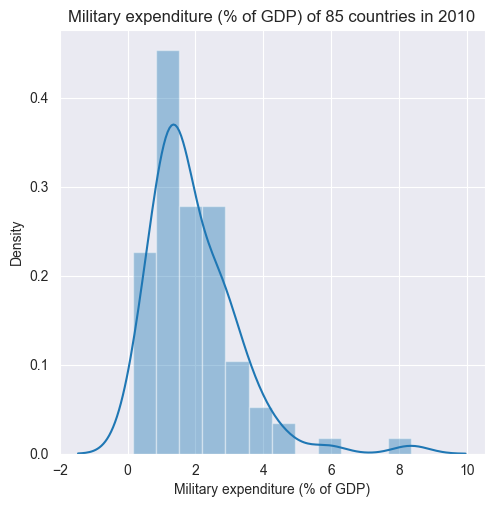

In [25]:
plt.figure(figsize=(5.5, 5.5))
g = sns.distplot(military_exp_np, norm_hist=False)
g.set_title('Military expenditure (% of GDP) of 85 countries in 2010');
plt.xlabel("Military expenditure (% of GDP)");

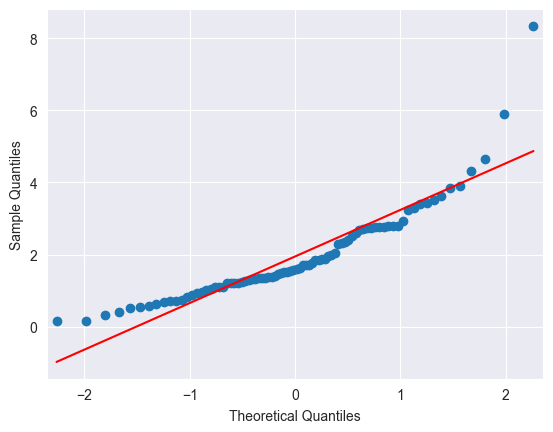

In [26]:
from statsmodels.graphics.gofplots import qqplot
qqplot(military_exp_np, line='s');

In [27]:
from scipy.stats import shapiro

print('Shapiro-Wilk Test:')
stat, p = shapiro(military_exp_np)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Shapiro-Wilk Test:
Statistics=0.857023, p=1.646573e-07
Sample does not look Normal (reject H0)


In [28]:
import numpy as np
from scipy import stats

print('Kolmogorov-Smirnov:')
stat, p = stats.kstest(military_exp_np, stats.norm.cdf)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Kolmogorov-Smirnov:
Statistics=0.659326, p=2.320049e-36
Sample does not look Normal (reject H0)


In [29]:
from scipy.stats import normaltest, kurtosis, skew

stat, p = normaltest(military_exp_np)
print('Statistics=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Gaussian (fail to reject H0)')
else:
 print('Sample does not look Gaussian (reject H0)')

print('Kurtosis=%.3f'%kurtosis(military_exp_np))
print('Skew=%.3f'%skew(military_exp_np))

Statistics=49.874, p=0.000
Sample does not look Gaussian (reject H0)
Kurtosis=6.122
Skew=1.916


## 1.3 Datos de series temporales

In [30]:
central_govt_debt_us = central_govt_debt.loc[central_govt_debt['Country Code']=='USA', :].T
military_exp_us = military_exp.loc[military_exp['Country Code']=='USA', :].T

In [31]:
data_us = pd.concat((military_exp_us, central_govt_debt_us), axis=1)
index0 = np.where(data_us.index=='1960')[0][0]
index1 = np.where(data_us.index=='2010')[0][0]
data_us = data_us.iloc[index0:index1+1,:]
data_us.columns = ['Federal Military Expenditure', 'Debt of Federal Government']
data_us.head()

,Federal Military Expenditure,Debt of Federal Government
1960,8.35266,NaN
1961,8.487129,NaN
1962,8.656586,NaN
1963,8.189007,NaN
1964,7.467629,NaN


In [32]:
data_us.isna().sum()

Federal Military Expenditure     0
Debt of Federal Government      29
dtype: int64

In [33]:
(data_us.isnull().sum()/len(data_us))*100

Federal Military Expenditure     0.000000
Debt of Federal Government      56.862745
dtype: float64

In [34]:
data_us['backward_fill'] = data_us['Debt of Federal Government'].bfill()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill
1960,8.35266,NaN,39.016963
1961,8.487129,NaN,39.016963
1962,8.656586,NaN,39.016963
1963,8.189007,NaN,39.016963
1964,7.467629,NaN,39.016963


In [35]:
data_us['mean_fill'] = data_us['Debt of Federal Government'].mean()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill
1960,8.35266,NaN,39.016963,51.155537
1961,8.487129,NaN,39.016963,51.155537
1962,8.656586,NaN,39.016963,51.155537
1963,8.189007,NaN,39.016963,51.155537
1964,7.467629,NaN,39.016963,51.155537


In [36]:
data_us['median_fill'] = data_us['Debt of Federal Government'].median()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,median_fill
1960,8.35266,NaN,39.016963,51.155537,47.659404
1961,8.487129,NaN,39.016963,51.155537,47.659404
1962,8.656586,NaN,39.016963,51.155537,47.659404
1963,8.189007,NaN,39.016963,51.155537,47.659404
1964,7.467629,NaN,39.016963,51.155537,47.659404


In [37]:
data_us['quadratic_fill'] = data_us['Debt of Federal Government'].interpolate(option='quadratic')
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,median_fill,quadratic_fill
1960,8.35266,NaN,39.016963,51.155537,47.659404,NaN
1961,8.487129,NaN,39.016963,51.155537,47.659404,NaN
1962,8.656586,NaN,39.016963,51.155537,47.659404,NaN
1963,8.189007,NaN,39.016963,51.155537,47.659404,NaN
1964,7.467629,NaN,39.016963,51.155537,47.659404,NaN


In [38]:
data_us.dropna(inplace=True)
print('Shape of data_us:', data_us.shape)

Shape of data_us: (22, 6)


In [39]:
data_us.head(10)

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,median_fill,quadratic_fill
1989,5.374717,39.016963,39.016963,51.155537,47.659404,39.016963
1990,5.120252,40.821367,40.821367,51.155537,47.659404,40.821367
1991,4.539845,43.948026,43.948026,51.155537,47.659404,43.948026
1992,4.666265,45.916542,45.916542,51.155537,47.659404,45.916542
1993,4.326925,48.104749,48.104749,51.155537,47.659404,48.104749
1994,3.941287,47.21406,47.214060,51.155537,47.659404,47.21406
1995,3.638489,47.059783,47.059783,51.155537,47.659404,47.059783
1996,3.350744,46.585511,46.585511,51.155537,47.659404,46.585511
1997,3.209903,43.958801,43.958801,51.155537,47.659404,43.958801
1998,3.017636,41.009914,41.009914,51.155537,47.659404,41.009914


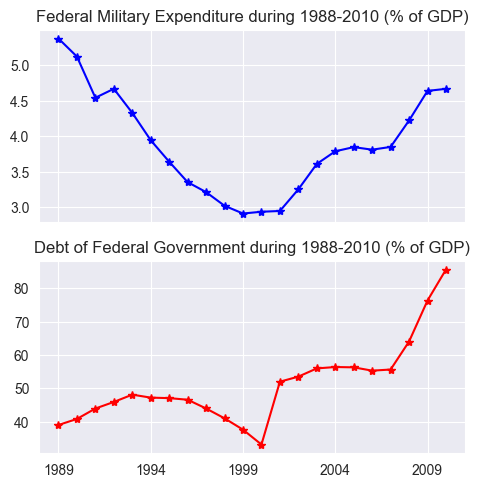

In [40]:
f, axarr = plt.subplots(2, sharex=True)
f.set_size_inches(5.5, 5.5)
axarr[0].set_title('Federal Military Expenditure during 1988-2010 (% of GDP)')
data_us['Federal Military Expenditure'].plot(linestyle='-', marker='*', color='b', ax=axarr[0])
axarr[1].set_title('Debt of Federal Government during 1988-2010 (% of GDP)')
data_us['Debt of Federal Government'].plot(linestyle='-', marker='*', color='r', ax=axarr[1]);

## 1.4 Datos de panel

In [41]:
chn = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='CHN'), :] #China
chn.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,Unnamed: 61
134507,China,CHN,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.878156,2.067426,1.896713,1.821927,1.838564,1.872334,1.915341,1.934922,1.922962,NaN


In [42]:
chn = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='CHN'), :].drop(data.columns[range(3)], axis=1)
chn.head()

,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,Unnamed: 61
134507,MS.MIL.XPND.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.878156,2.067426,1.896713,1.821927,1.838564,1.872334,1.915341,1.934922,1.922962,NaN


In [43]:
chn = pd.Series(data=chn.values[0], index=chn.columns)
chn.dropna(inplace=True)
chn.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1989                       2.499185
1990                       2.555996
1991                       2.407892
1992                       2.518629
dtype: object

In [44]:
usa = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='USA'), :].drop(data.columns[range(3)], axis=1) #USA
usa = pd.Series(data=usa.values[0], index=usa.columns)
usa.dropna(inplace=True)
usa.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1960                        8.35266
1961                       8.487129
1962                       8.656586
1963                       8.189007
dtype: object

In [45]:
ind = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='IND'), :].drop(data.columns[range(3)], axis=1) #India
ind = pd.Series(data=ind.values[0], index=ind.columns)
ind.dropna(inplace=True)
ind.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1960                       1.866015
1961                       1.933365
1962                       2.561202
1963                       3.758057
dtype: object

In [46]:
gbr = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='GBR'), :].drop(data.columns[range(3)], axis=1) #United Kingdom
gbr = pd.Series(data=gbr.values[0], index=gbr.columns)
gbr.dropna(inplace=True)
gbr.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1960                       6.343041
1961                       6.190022
1962                       6.210394
1963                       6.082126
dtype: object

In [47]:
n_years = chn.shape[0]
print("#Years: ", n_years+1)

#Years:  30


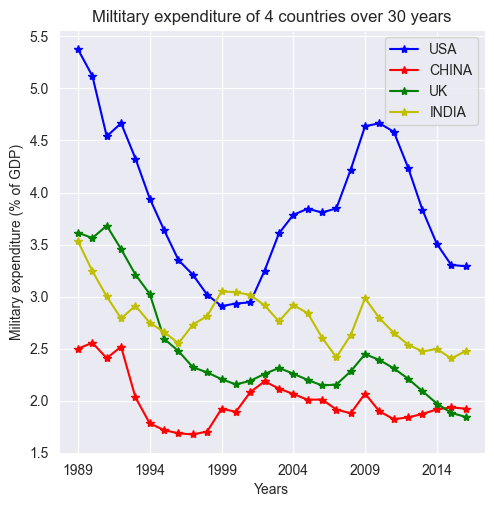

In [48]:
plt.figure(figsize=(5.5, 5.5))
usa[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='b')
chn[1:n_years].plot(linestyle='-', marker='*', color='r')
gbr[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='g')
ind[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='y')
plt.legend(['USA','CHINA','UK','INDIA'], loc=1)
plt.title('Miltitary expenditure of 4 countries over 30 years')
plt.ylabel('Military expenditure (% of GDP)')
plt.xlabel('Years');

## 1.6 Tendencia general

In [49]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [50]:
data = pd.read_excel('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\Monthly_CO2_Concentrations.xlsx', converters={'Year': np.int32, 'Month': np.int32})

In [51]:
data.head()

,CO2,Year,Month
0,333.13,1974,5
1,332.09,1974,6
2,331.10,1974,7
3,329.14,1974,8
4,327.36,1974,9


In [52]:
data.index = data['Year'].astype(str) + '-' + data['Month'].astype(str).map(lambda x: '0'+x if len(x) == 1 else x)
data.head()

,CO2,Year,Month
1974-05,333.13,1974,5
1974-06,332.09,1974,6
1974-07,331.10,1974,7
1974-08,329.14,1974,8
1974-09,327.36,1974,9


In [53]:
data = data.loc[(~pd.isnull(data['CO2'])) & \
                (~pd.isnull(data['Year']))& \
                (~pd.isnull(data['Month']))]

In [54]:
data.sort_values(['Year', 'Month'], inplace=True)

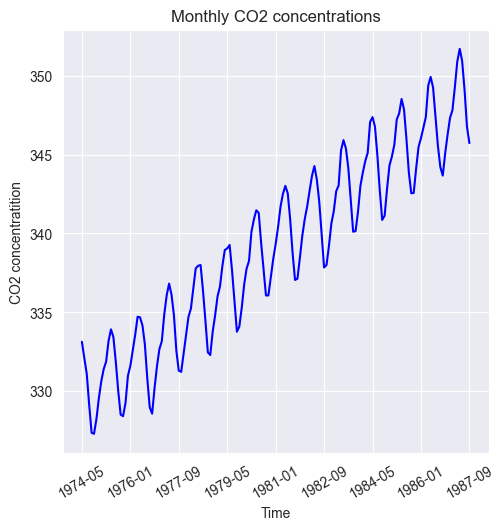

In [55]:
plt.figure(figsize=(5.5, 5.5))
data['CO2'].plot(color='b')
plt.title('Monthly CO2 concentrations')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

In [56]:
data.index = pd.to_datetime(data.index, format='%Y-%m')
frecuencia = pd.infer_freq(data.index)
print("Frecuencia: ", frecuencia)

Frecuencia:  MS


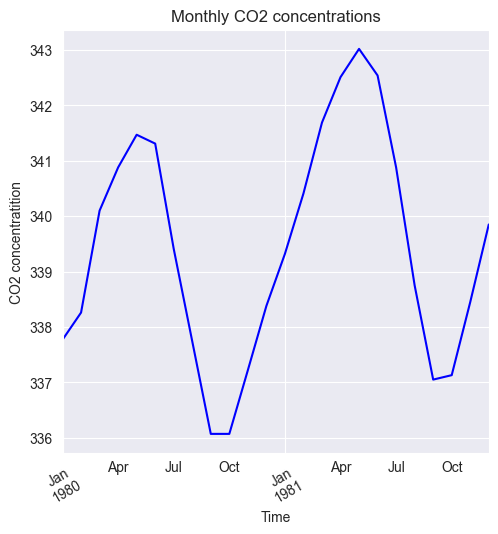

In [57]:
plt.figure(figsize=(5.5, 5.5))
data['CO2'].loc[(data['Year']==1980) | (data['Year']==1981)].plot(color='b')
plt.title('Monthly CO2 concentrations')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

In [61]:
pip install -U sklearn-learn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn-learn (from versions: none)
ERROR: No matching distribution found for sklearn-learn


In [60]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [62]:
trend_model = LinearRegression(fit_intercept=True)
trend_model.fit(np.arange(data.shape[0]).reshape((-1,1)), data['CO2'])

LinearRegression()

In [63]:
print('Trend model coefficient={} and intercept={}'.format(trend_model.coef_[0], trend_model.intercept_))

Trend model coefficient=0.1209930124223602 and intercept=329.45310559006214


In [64]:
residuals = np.array(data['CO2']) - trend_model.predict(np.arange(data.shape[0]).reshape((-1,1)))

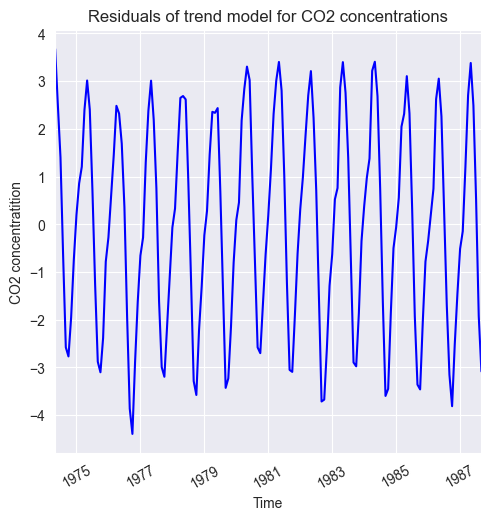

In [65]:
plt.figure(figsize=(5.5, 5.5))
pd.Series(data=residuals, index=data.index).plot(color='b')
plt.title('Residuals of trend model for CO2 concentrations')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

## 1.8 Grafico de secuencia de series 

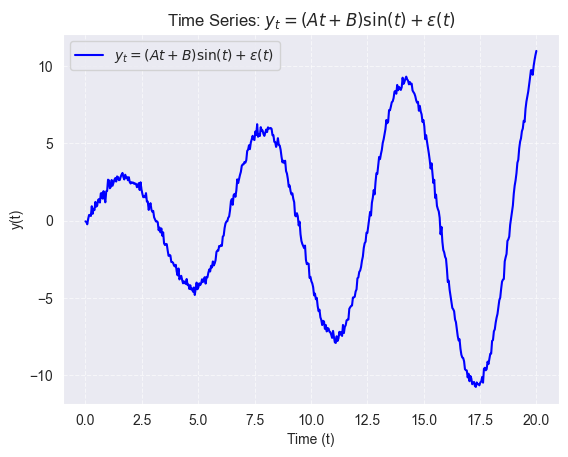

In [66]:
import numpy as np
import matplotlib.pyplot as plt

A = 0.5 
B = 2.0 
t = np.linspace(0, 20, 500)  
epsilon = np.random.normal(0, 0.2, len(t))

y_t = (A * t + B) * np.sin(t) + epsilon

plt.figure()
plt.plot(t, y_t, label=r'$y_{t} = (At + B)\sin(t) + \varepsilon(t)$', color='blue')
plt.title("Time Series: $y_{t} = (At + B)\\sin(t) + \\varepsilon(t)$")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 1.9 Gráfico de subserie estacional

In [67]:
data.head()

,CO2,Year,Month
1974-05-01,333.13,1974,5
1974-06-01,332.09,1974,6
1974-07-01,331.10,1974,7
1974-08-01,329.14,1974,8
1974-09-01,327.36,1974,9


In [68]:
data['Residuals'] = residuals
month_quarter_map = {1: 'Q1', 2: 'Q1', 3: 'Q1',
                     4: 'Q2', 5: 'Q2', 6: 'Q2',
                     7: 'Q3', 8: 'Q3', 9: 'Q3',
                     10: 'Q4', 11: 'Q4', 12: 'Q4'}
data['Quarter'] = data['Month'].map(lambda m: month_quarter_map.get(m))

In [69]:
seasonal_sub_series_data = data.groupby(by=['Year', 'Quarter'])['Residuals'].aggregate([np.mean, np.std])
seasonal_sub_series_data.columns = ['Quarterly Mean', 'Quarterly Standard Deviation']

In [70]:
seasonal_sub_series_data.reset_index(inplace=True)
seasonal_sub_series_data.index = seasonal_sub_series_data['Year'].astype(str) + '-' + seasonal_sub_series_data['Quarter']
seasonal_sub_series_data.head()

,Year,Quarter,Quarterly Mean,Quarterly Standard Deviation
1974-Q2,1974,Q2,3.096398,0.820946
1974-Q3,1974,Q3,-0.616085,1.991671
1974-Q4,1974,Q4,-1.822397,1.014952
1975-Q1,1975,Q1,0.754624,0.511890
1975-Q2,1975,Q2,2.604978,0.355093


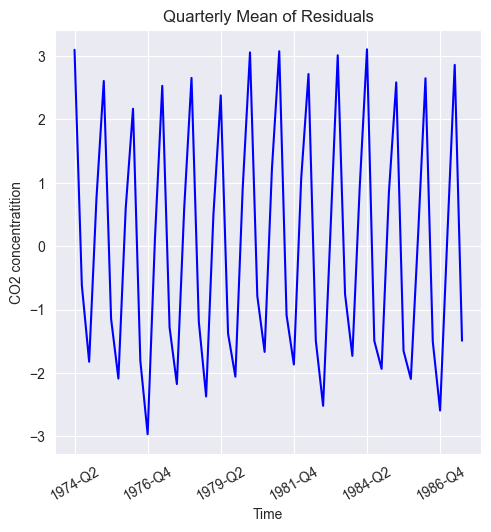

In [71]:
plt.figure(figsize=(5.5, 5.5))
seasonal_sub_series_data['Quarterly Mean'].plot(color='b')
plt.title('Quarterly Mean of Residuals')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

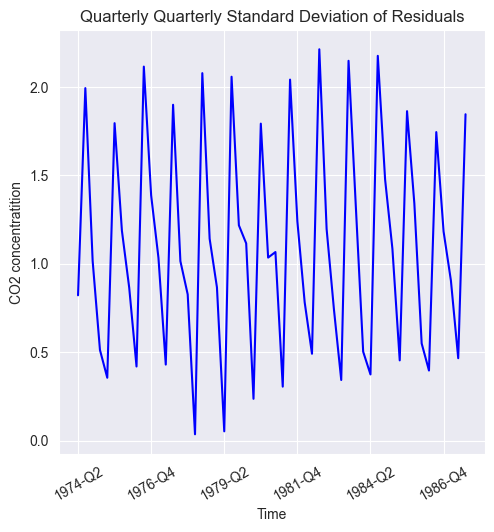

In [72]:
plt.figure(figsize=(5.5, 5.5))
seasonal_sub_series_data['Quarterly Standard Deviation'].plot(color='b')
plt.title('Quarterly Quarterly Standard Deviation of Residuals')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

## 1.10 Gráfico de cajas múltiples

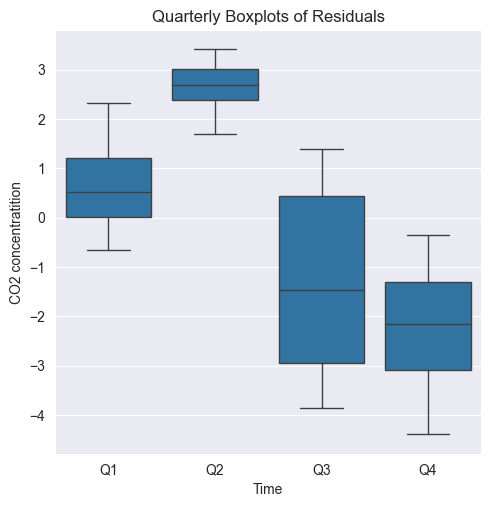

In [73]:
plt.figure(figsize=(5.5, 5.5))
g = sns.boxplot(data=data[data['Year'] > 1974], y='Residuals', x='Quarter')
g.set_title('Quarterly Boxplots of Residuals')
g.set_xlabel('Time')
g.set_ylabel('CO2 concentratition');

## 1.11 Cambios cíclicos

In [74]:
inflation = pd.read_excel('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\inflation-consumer-prices-annual.xlsx', parse_dates=['Year'])

In [75]:
inflation.head()

,Year,India,United States
0,1960-01-01,1.783265,1.509929
1,1961-01-01,1.752022,1.075182
2,1962-01-01,3.576159,1.116071
3,1963-01-01,2.941176,1.214128
4,1964-01-01,13.354037,1.308615


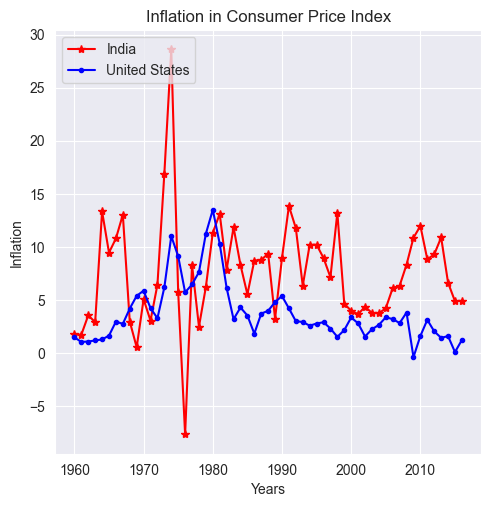

In [76]:
plt.figure(figsize=(5.5, 5.5))
plt.plot(range(1960,2017), inflation['India'], linestyle='-', marker='*', color='r')
plt.plot(range(1960,2017), inflation['United States'], linestyle='-', marker='.', color='b')
plt.legend(['India','United States'], loc=2)
plt.title('Inflation in Consumer Price Index')
plt.ylabel('Inflation')
plt.xlabel('Years');

## 1.12 Componentes irregulares

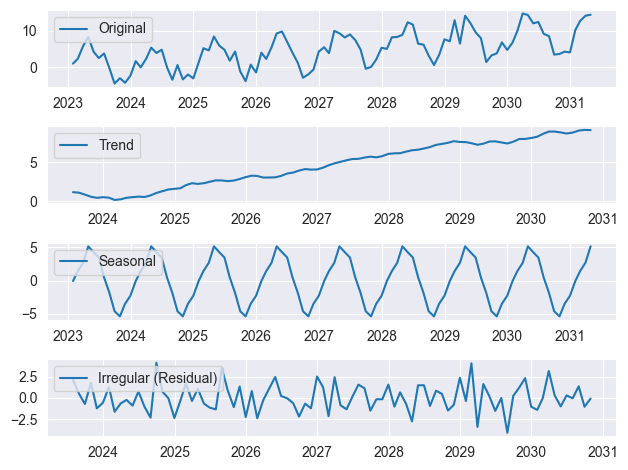

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)
n = 100
time = np.arange(n)

trend = 0.1 * time  
seasonality = 5 * np.sin(2 * np.pi * time / 12)  
irregular = np.random.normal(0, 2, n)

series = trend + seasonality + irregular

date_range = pd.date_range(start="2023-01-01", periods=n, freq='M')
data = pd.DataFrame({'Date': date_range, 'Value': series}).set_index('Date')

decomposition = seasonal_decompose(data['Value'], model='additive', period=12)

plt.figure()
plt.subplot(411)
plt.plot(data['Value'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Irregular (Residual)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 1.14 Modelos de media cero

In [78]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [79]:
np.random.seed(42)
zero_mean_series = np.random.normal(loc=0.0, scale=1., size=100)

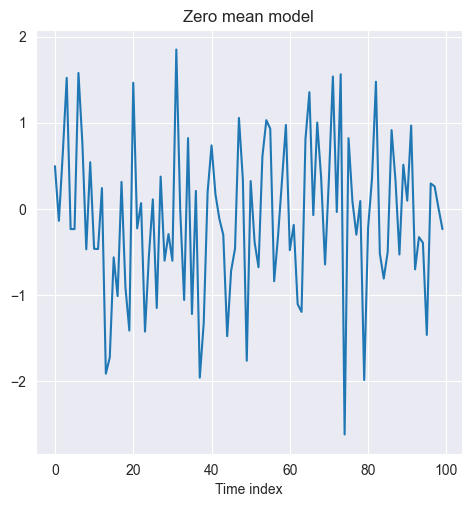

In [80]:
plt.figure(figsize=(5.5, 5.5))
g = sns.lineplot(zero_mean_series)
g.set_title('Zero mean model')
g.set_xlabel('Time index');

## 1.15 Camino aleatorio

In [81]:
random_walk = np.cumsum(zero_mean_series)

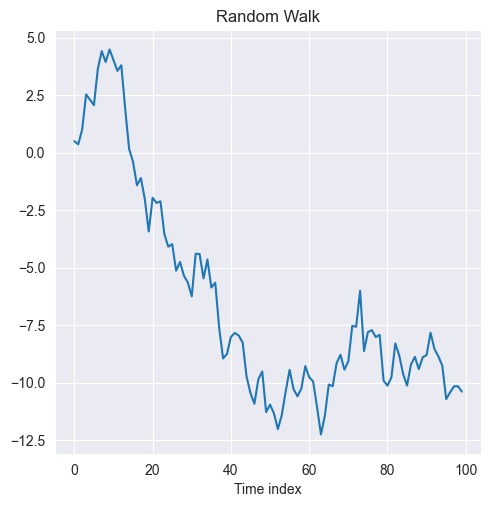

In [82]:
plt.figure(figsize=(5.5, 5.5))
g = sns.lineplot(random_walk)
g.set_title('Random Walk')
g.set_xlabel('Time index');

## 1.16 Modelos de tendencia

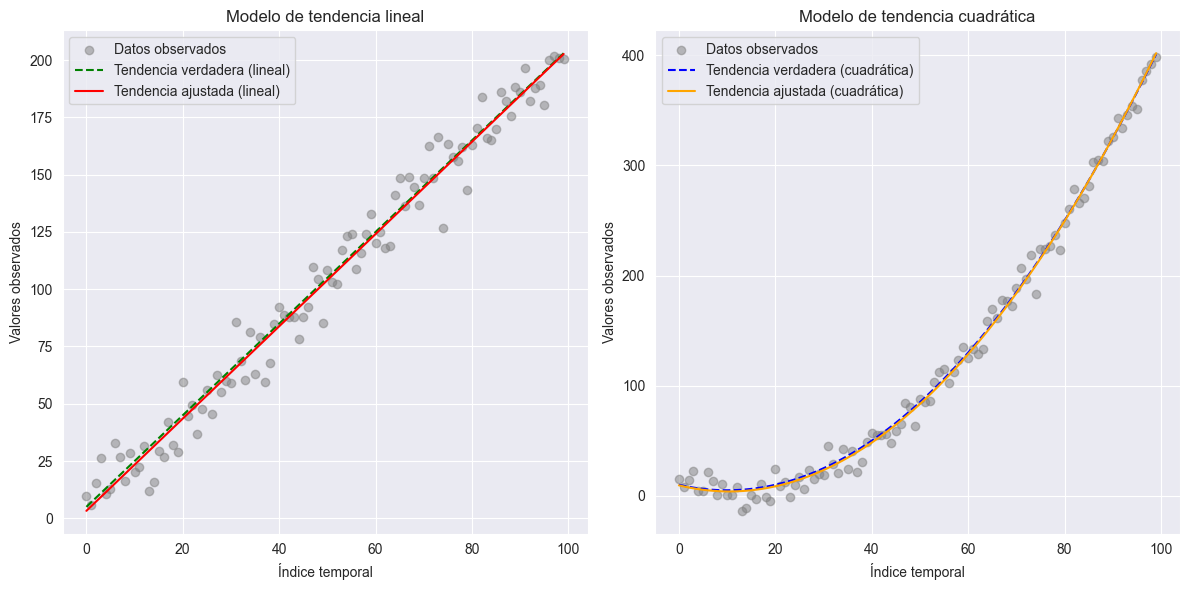

In [83]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
t = np.arange(0, 100, 1)  
true_trend_linear = 2 * t + 5  # Modelo de tendencia lineal: µ(t) = 2t + 5
true_trend_quadratic = 0.05 * t**2 - t + 10  # Modelo cuadrático: µ(t) = 0.05t^2 - t + 10

noise = np.random.normal(0, 10, size=len(t))
y_linear = true_trend_linear + noise  # Serie con tendencia lineal
y_quadratic = true_trend_quadratic + noise  # Serie con tendencia cuadrática

# Modelo lineal: y = wt + b
coeffs_linear = np.polyfit(t, y_linear, 1)  # Grado 1
fitted_trend_linear = np.polyval(coeffs_linear, t)

# Modelo cuadrático: y = w1t + w2t^2 + b
coeffs_quadratic = np.polyfit(t, y_quadratic, 2)  # Grado 2
fitted_trend_quadratic = np.polyval(coeffs_quadratic, t)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(t, y_linear, color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, true_trend_linear, color='green', label='Tendencia verdadera (lineal)', linestyle='dashed')
plt.plot(t, fitted_trend_linear, color='red', label='Tendencia ajustada (lineal)')
plt.title('Modelo de tendencia lineal')
plt.xlabel('Índice temporal')
plt.ylabel('Valores observados')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t, y_quadratic, color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, true_trend_quadratic, color='blue', label='Tendencia verdadera (cuadrática)', linestyle='dashed')
plt.plot(t, fitted_trend_quadratic, color='orange', label='Tendencia ajustada (cuadrática)')
plt.title('Modelo de tendencia cuadrática')
plt.xlabel('Índice temporal')
plt.ylabel('Valores observados')
plt.legend()

plt.tight_layout()
plt.show()

## 1.19 Experimentos numéricos ACF

In [84]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [85]:
djia_df = pd.read_excel(r'C:\Users\cospi\OneDrive\Escritorio\Msc_Economics\Semestre_III\Time_Series\DJIA_Jan2016_Dec2016.xlsx')

In [86]:
djia_df.index = djia_df['Date']
djia_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2016-01-04,2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
2016-01-05,2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2016-01-06,2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
2016-01-07,2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
2016-01-08,2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


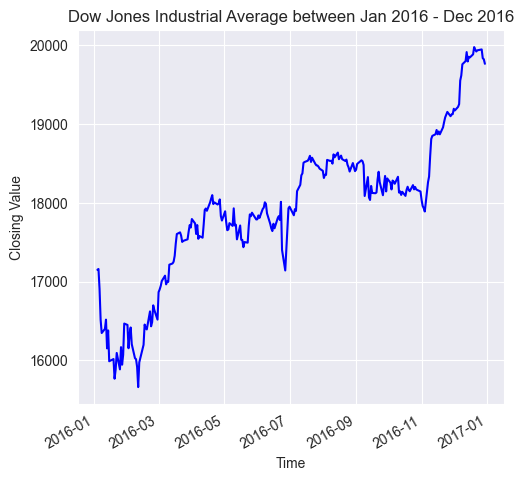

In [87]:
plt.figure(figsize=(5.5, 5.5))
djia_df['Close'].plot(color='b')
plt.title('Dow Jones Industrial Average between Jan 2016 - Dec 2016')
plt.xlabel('Time')
plt.ylabel('Closing Value');

In [88]:
lag = range(0,31)
djia_acf = []
for l in lag:
    djia_acf.append(djia_df['Close'].autocorr(l))

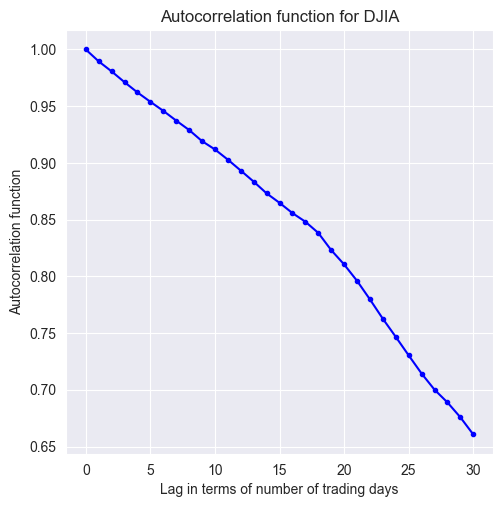

In [89]:
plt.figure(figsize=(5.5, 5.5))
plt.plot(djia_acf, marker='.', color='b')
plt.title('Autocorrelation function for DJIA')
plt.xlabel('Lag in terms of number of trading days')
plt.ylabel('Autocorrelation function');

<Figure size 550x550 with 0 Axes>

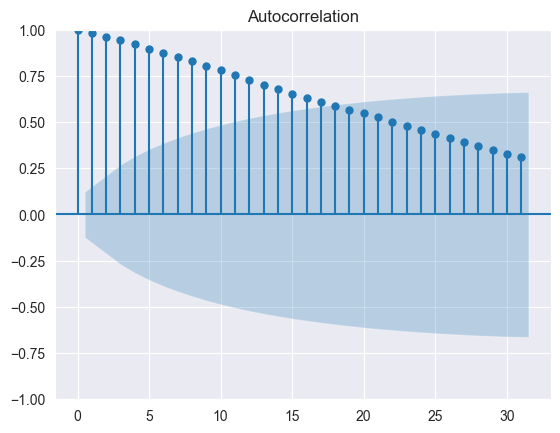

In [90]:
plt.figure(figsize=(5.5, 5.5));
plot_acf(djia_df['Close'], lags=31);

<Figure size 550x550 with 0 Axes>

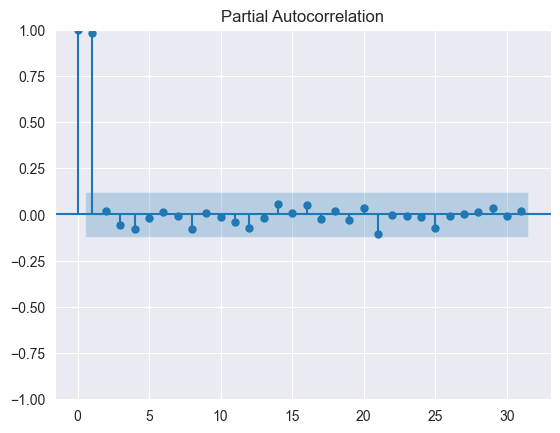

In [91]:
plt.figure(figsize=(5.5, 5.5));
plot_pacf(djia_df['Close'], lags=31);

## 1.22 Remuestreo de datos de series temporales

In [92]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [94]:
df = pd.read_csv(r'C:\Users\cospi\OneDrive\Escritorio\Msc_Economics\Semestre_III\Time_Series\chemical-concentration-readings.csv')
print('Shape of the dataset:', df.shape)
df.head()

Shape of the dataset: (197, 2)


,Timestamp,Chemical conc.
0,1975-01-01 00:00:00,17.0
1,1975-01-01 02:00:00,16.6
2,1975-01-01 04:00:00,16.3
3,1975-01-01 06:00:00,16.1
4,1975-01-01 08:00:00,17.1


In [95]:
datetime_rowid = df['Timestamp'].map(lambda t: pd.to_datetime(t, format='%Y-%m-%d %H:%M:%S'))
df.index = datetime_rowid
df.head()

,Timestamp,Chemical conc.
Timestamp,,
1975-01-01 00:00:00,1975-01-01 00:00:00,17.0
1975-01-01 02:00:00,1975-01-01 02:00:00,16.6
1975-01-01 04:00:00,1975-01-01 04:00:00,16.3
1975-01-01 06:00:00,1975-01-01 06:00:00,16.1
1975-01-01 08:00:00,1975-01-01 08:00:00,17.1


In [96]:
daily = df['Chemical conc.'].resample('D')
daily_mean = daily.mean()

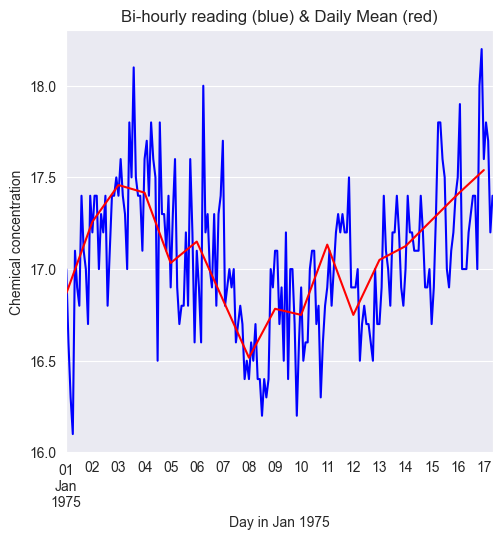

In [97]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
df['Chemical conc.'].plot(ax=ax, color='b')
daily_mean.plot(ax=ax, color='r')
ax.set_title('Bi-hourly reading (blue) & Daily Mean (red)');
ax.set_xlabel('Day in Jan 1975');
ax.set_ylabel('Chemical concentration');

## 1.23 Agregación por grupos

In [99]:
df = pd.read_csv(r'C:\Users\cospi\OneDrive\Escritorio\Msc_Economics\Semestre_III\Time_Series\mean-daily-temperature-fisher-river.csv')
df.index = df['Date'].map(lambda d: pd.to_datetime(d, format = '%Y-%m-%d'))

In [100]:
print('Shape of dataframe:', df.shape)
df.head()

Shape of dataframe: (1461, 2)


,Date,Mean temperature
Date,,
1988-01-01,1988-01-01,-23.0
1988-01-02,1988-01-02,-20.5
1988-01-03,1988-01-03,-22.0
1988-01-04,1988-01-04,-30.5
1988-01-05,1988-01-05,-31.0


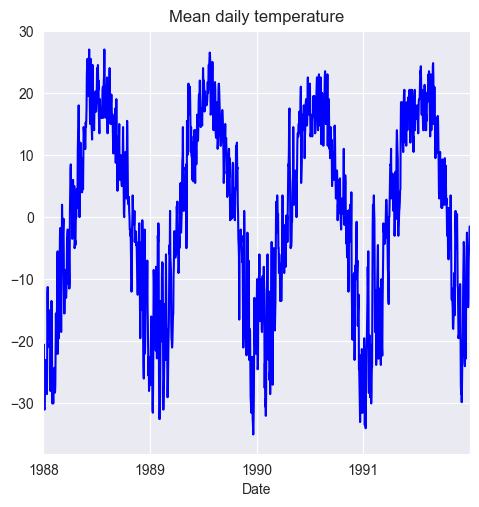

In [101]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
df['Mean temperature'].plot(ax=ax, color='b')
ax.set_title('Mean daily temperature');

In [102]:
df['Month_Year'] = df.index.map(lambda d: d.strftime('%m-%Y'))
df.head()

,Date,Mean temperature,Month_Year
Date,,,
1988-01-01,1988-01-01,-23.0,01-1988
1988-01-02,1988-01-02,-20.5,01-1988
1988-01-03,1988-01-03,-22.0,01-1988
1988-01-04,1988-01-04,-30.5,01-1988
1988-01-05,1988-01-05,-31.0,01-1988


In [103]:
monthly_stats = df.groupby(by='Month_Year')['Mean temperature'].aggregate([np.mean, np.median, np.std])
monthly_stats.reset_index(inplace=True)
monthly_stats.head()

,Month_Year,mean,median,std
0,01-1988,-22.137097,-23.0,5.260640
1,01-1989,-17.129032,-18.0,8.250725
2,01-1990,-15.112903,-12.0,6.606764
3,01-1991,-23.038710,-24.5,7.095570
4,02-1988,-19.025862,-19.5,8.598522


In [104]:
monthly_stats['Year'] = monthly_stats['Month_Year']\
.map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%Y'))

monthly_stats['Month'] = monthly_stats['Month_Year']\
.map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%m'))

monthly_stats.sort_values(by=['Year', 'Month'], inplace=True)
monthly_stats.head()

,Month_Year,mean,median,std,Year,Month
0,01-1988,-22.137097,-23.000,5.260640,1988,01
4,02-1988,-19.025862,-19.500,8.598522,1988,02
8,03-1988,-8.258065,-9.250,5.341459,1988,03
12,04-1988,2.641667,1.875,5.057720,1988,04
16,05-1988,11.290323,11.000,6.254364,1988,05


In [105]:
monthly_stats.index = monthly_stats['Month_Year']

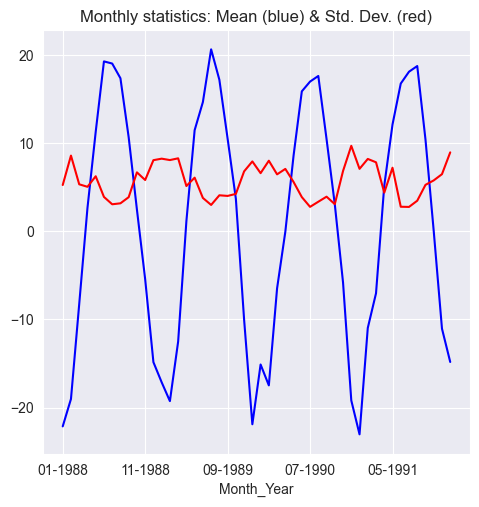

In [106]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)

monthly_stats['mean'].plot(ax=ax, color='b')
monthly_stats['std'].plot(ax=ax, color='r')

ax.set_title('Monthly statistics: Mean (blue) & Std. Dev. (red)');

## 1.24 Estadísticos móviles

In [107]:
weekly_moving_average = df['Mean temperature'].rolling(7).mean()

In [108]:
monthly_moving_average = df['Mean temperature'].rolling(30).mean()

In [109]:
weekly_moving_average_2stride = df['Mean temperature'].rolling(7).mean()[::2]

In [110]:
monthly_moving_average_2stride = df['Mean temperature'].rolling(30).mean()[::2]

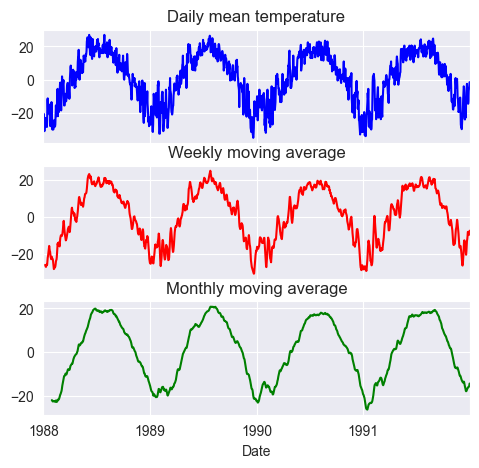

In [111]:
fig, axarr = plt.subplots(3, sharex=True)
fig.set_size_inches(5.5, 5,5)

df['Mean temperature'].plot(ax=axarr[0], color='b')
axarr[0].set_title('Daily mean temperature');

weekly_moving_average.plot(ax=axarr[1], color='r')
axarr[1].set_title('Weekly moving average');

monthly_moving_average.plot(ax=axarr[2], color='g')
axarr[2].set_title('Monthly moving average');

## 1.25 Procesos estacionarios

In [112]:
from random import seed
from pandas import Series
import random 
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

In [113]:
seed(1)
series = [random.gauss(0.0, 1.0) for i in range(1000)]
series = Series(series)
series.describe()

count    1000.000000
mean       -0.013222
std         1.003685
min        -2.961214
25%        -0.684192
50%        -0.010934
75%         0.703915
max         2.737260
dtype: float64

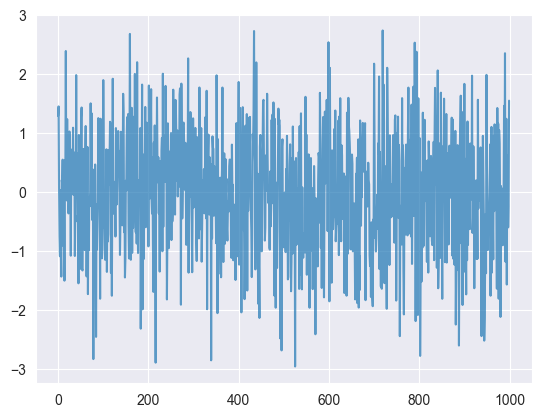

In [114]:
series.plot(alpha=0.7);

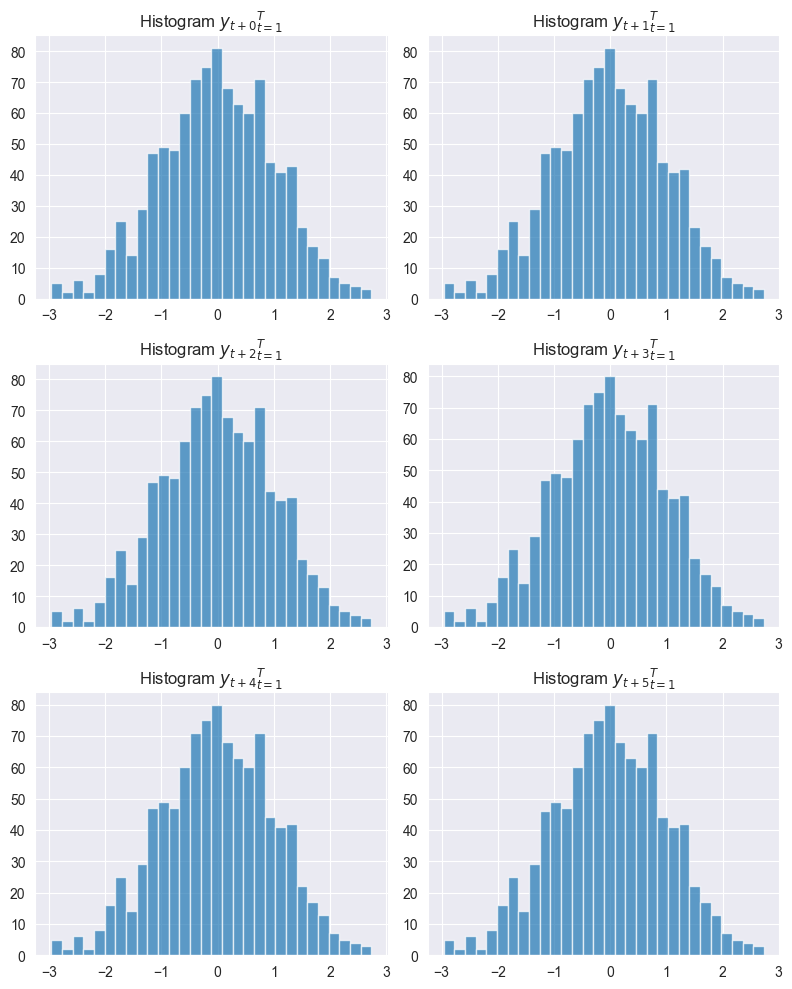

In [117]:
plt.rcParams['text.usetex'] = False
fig, axs = plt.subplots(3, 2, figsize=(8, 10))

for i, ax in enumerate(axs.flat):
    ax.hist(series[i:], bins=30, alpha=0.7)
    ax.set_title(rf'Histogram ${{y_{{t+{i}}}}}_{{t=1}}^T$')

plt.tight_layout()
plt.show()

## 1.28 Diferenciación 

In [118]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from matplotlib import pyplot as plt
from pandas.plotting import autocorrelation_plot

In [119]:
djia_df = pd.read_excel(r'C:\Users\cospi\OneDrive\Escritorio\Msc_Economics\Semestre_III\Time_Series\DJIA_Jan2016_Dec2016.xlsx')

In [120]:
djia_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
1,2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2,2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
3,2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
4,2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


In [121]:
djia_df['Date'] = pd.to_datetime(djia_df['Date'], '%Y-%m-%d')
djia_df.index = djia_df['Date']
djia_df.drop('Date', axis=1, inplace=True)
djia_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


In [122]:
first_order_diff = djia_df['Close'].diff(1)

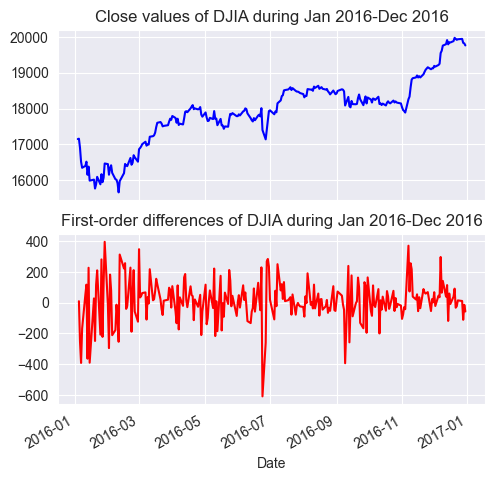

In [123]:
fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(5.5, 5.5)
djia_df['Close'].plot(ax=ax[0], color='b');
ax[0].set_title('Close values of DJIA during Jan 2016-Dec 2016');
first_order_diff.plot(ax=ax[1], color='r');
ax[1].set_title('First-order differences of DJIA during Jan 2016-Dec 2016');

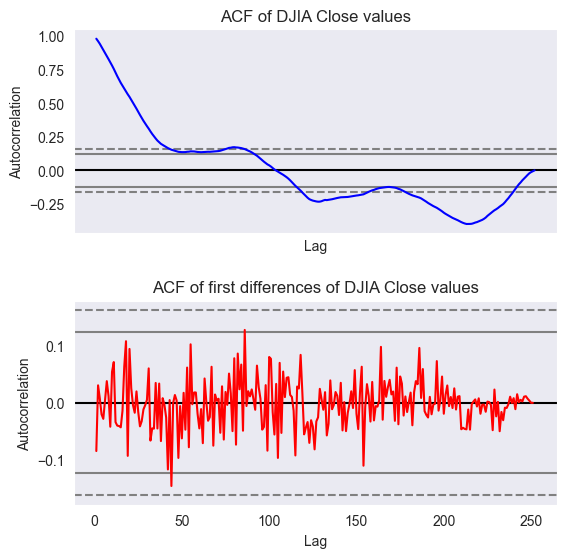

In [124]:
fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(5.5, 5.5)
autocorrelation_plot(djia_df['Close'], color='b', ax=ax[0])
ax[0].set_title('ACF of DJIA Close values')
autocorrelation_plot(first_order_diff.iloc[1:], color='r', ax=ax[1])
ax[1].set_title('ACF of first differences of DJIA Close values')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [125]:
acf_djia, confint_djia, qstat_djia, pvalues_djia = stattools.acf(djia_df['Close'],
                                                                 nlags=20,
                                                                 qstat=True,
                                                                 alpha=0.05)

In [126]:
alpha = 0.05
for l, p_val in enumerate(pvalues_djia):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is rejected at lag = 0 for p-val = 2.8575062763851745e-55
Null hypothesis is rejected at lag = 1 for p-val = 1.7871763971271254e-105
Null hypothesis is rejected at lag = 2 for p-val = 9.927155881909959e-154
Null hypothesis is rejected at lag = 3 for p-val = 8.084096278834598e-200
Null hypothesis is rejected at lag = 4 for p-val = 9.125287802249553e-244
Null hypothesis is rejected at lag = 5 for p-val = 1.0907828815951678e-285
Null hypothesis is rejected at lag = 6 for p-val = 0.0
Null hypothesis is rejected at lag = 7 for p-val = 0.0
Null hypothesis is rejected at lag = 8 for p-val = 0.0
Null hypothesis is rejected at lag = 9 for p-val = 0.0
Null hypothesis is rejected at lag = 10 for p-val = 0.0
Null hypothesis is rejected at lag = 11 for p-val = 0.0
Null hypothesis is rejected at lag = 12 for p-val = 0.0
Null hypothesis is rejected at lag = 13 for p-val = 0.0
Null hypothesis is rejected at lag = 14 for p-val = 0.0
Null hypothesis is rejected at lag = 15 for p-val = 0.

In [127]:
acf_first_diff, confint_first_diff,\
qstat_first_diff, pvalues_first_diff = stattools.acf(first_order_diff.iloc[1:],
                                                     nlags=20,
                                                     qstat=True,
                                                     alpha=0.05)

In [128]:
alpha = 0.05
for l, p_val in enumerate(pvalues_first_diff):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is accepted at lag = 0 for p-val = 0.17742519268365267
Null hypothesis is accepted at lag = 1 for p-val = 0.35711074717194824
Null hypothesis is accepted at lag = 2 for p-val = 0.55696644766949
Null hypothesis is accepted at lag = 3 for p-val = 0.7025937592112144
Null hypothesis is accepted at lag = 4 for p-val = 0.7937258941281413
Null hypothesis is accepted at lag = 5 for p-val = 0.880645293990265
Null hypothesis is accepted at lag = 6 for p-val = 0.9058055508095895
Null hypothesis is accepted at lag = 7 for p-val = 0.9461503874902826
Null hypothesis is accepted at lag = 8 for p-val = 0.9529107001186853
Null hypothesis is accepted at lag = 9 for p-val = 0.9452880323047996
Null hypothesis is accepted at lag = 10 for p-val = 0.9103701842715781
Null hypothesis is accepted at lag = 11 for p-val = 0.9303312940619602
Null hypothesis is accepted at lag = 12 for p-val = 0.9412519715905938
Null hypothesis is accepted at lag = 13 for p-val = 0.9498882104867831
Null hypothesis i

In [130]:
daily_temp = pd.read_excel('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\mean-daily-temperature-fisher-river.xlsx')
daily_temp.head()

,Date,Mean_Temperature
0,1988-01-01,-23.0
1,1988-01-02,-20.5
2,1988-01-03,-22.0
3,1988-01-04,-30.5
4,1988-01-05,-31.0


In [131]:
daily_temp.index = daily_temp['Date'].map(lambda date: pd.to_datetime(date, '%Y-%m-%d'))
daily_temp.drop('Date', axis=1, inplace=True)
daily_temp.head()

,Mean_Temperature
Date,
1988-01-01,-23.0
1988-01-02,-20.5
1988-01-03,-22.0
1988-01-04,-30.5
1988-01-05,-31.0


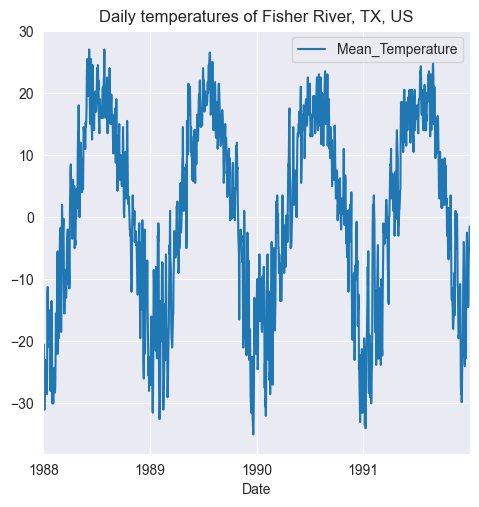

In [132]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Daily temperatures of Fisher River, TX, US');
daily_temp.plot(ax=ax);

In [133]:
montly_resample = daily_temp['Mean_Temperature'].resample('M')
monthly_mean_temp = montly_resample.mean()
print('Shape of monthly mean temperature dataset:', monthly_mean_temp.shape)
monthly_mean_temp.head()

Shape of monthly mean temperature dataset: (48,)


Date
1988-01-31   -22.137097
1988-02-29   -19.025862
1988-03-31    -8.258065
1988-04-30     2.641667
1988-05-31    11.290323
Freq: ME, Name: Mean_Temperature, dtype: float64

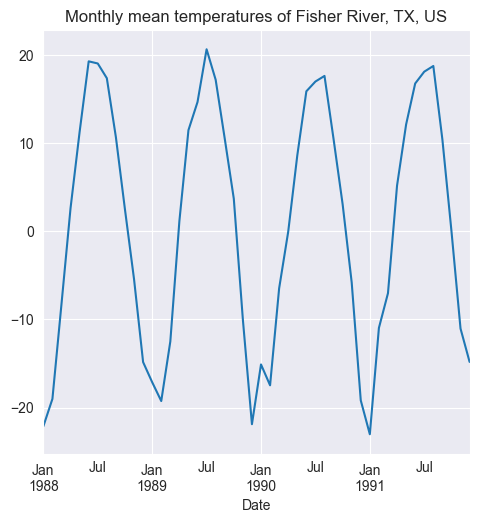

In [134]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Monthly mean temperatures of Fisher River, TX, US')
monthly_mean_temp.plot(ax=ax);

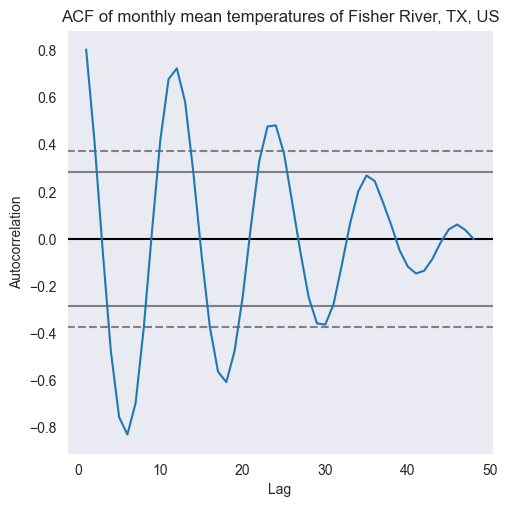

In [135]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of monthly mean temperatures of Fisher River, TX, US')
autocorrelation_plot(monthly_mean_temp, ax=ax);

In [136]:
seasonal_diff = monthly_mean_temp.diff(12)
seasonal_diff = seasonal_diff[12:]

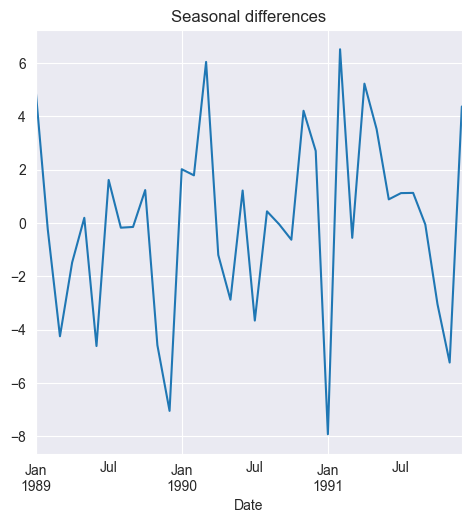

In [137]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Seasonal differences');
seasonal_diff.plot(ax=ax);

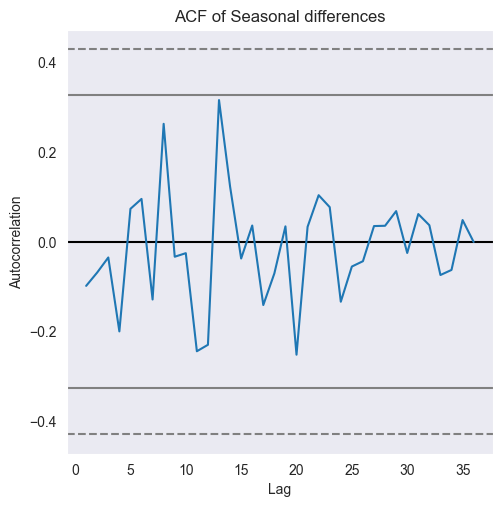

In [138]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of Seasonal differences');
autocorrelation_plot(seasonal_diff, ax=ax);

In [139]:
_, _, _, pval_monthly_mean = stattools.acf(monthly_mean_temp,
                                           nlags=10, 
                                           qstat=True, 
                                           alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean<=0.05))

Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),)


In [140]:
_, _, _, pval_seasonal_diff = stattools.acf(seasonal_diff,
                                            nlags=10, 
                                            qstat=True, 
                                            alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_seasonal_diff<=0.05))

Null hypothesis is rejected for lags: (array([], dtype=int64),)


## 1.9 Prueba Dickey-Fuller

In [141]:
air_miles = pd.read_csv('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\us-airlines-monthly-aircraft-miles-flown.csv')
air_miles.index = air_miles.Month

In [142]:
print('Shape of the DataFrame:', air_miles.shape)
air_miles.head()

Shape of the DataFrame: (97, 2)


,Month,U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970
Month,,
1963-01,1963-01,6827.0
1963-02,1963-02,6178.0
1963-03,1963-03,7084.0
1963-04,1963-04,8162.0
1963-05,1963-05,8462.0


In [143]:
air_miles.rename(columns={'U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970':\
                          'Air miles flown'}, inplace=True)

In [144]:
missing = pd.isnull(air_miles['Air miles flown'])
print('Number of missing values found:', missing.sum())
air_miles = air_miles.loc[~missing, :]

Number of missing values found: 1


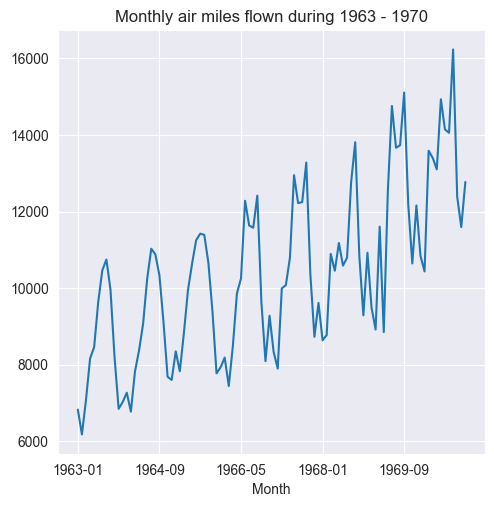

In [145]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
air_miles['Air miles flown'].plot(ax=ax)
ax.set_title('Monthly air miles flown during 1963 - 1970');

In [146]:
adf_result = stattools.adfuller(air_miles['Air miles flown'], autolag='AIC')

In [147]:
print('p-val of the ADF test in air miles flown:', adf_result[1])

p-val of the ADF test in air miles flown: 0.9945022811234028


## 1.31 Medias móviles y efectos de suavización 

In [148]:
import pandas as pd
from matplotlib import pyplot as plt

In [149]:
ibm_df = pd.read_csv('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\ibm-common-stock-closing-prices.csv')
ibm_df.index = ibm_df['Date']

In [150]:
print('Shape of the dataframe:', ibm_df.shape)
ibm_df.head()

Shape of the dataframe: (1009, 2)


,Date,IBM common stock closing prices
Date,,
1962-01-02,1962-01-02,572.00
1962-01-03,1962-01-03,577.00
1962-01-04,1962-01-04,571.25
1962-01-05,1962-01-05,560.00
1962-01-08,1962-01-08,549.50


In [151]:
ibm_df.rename(columns={'IBM common stock closing prices': 'Close_Price'}, inplace=True)
ibm_df.head()

,Date,Close_Price
Date,,
1962-01-02,1962-01-02,572.00
1962-01-03,1962-01-03,577.00
1962-01-04,1962-01-04,571.25
1962-01-05,1962-01-05,560.00
1962-01-08,1962-01-08,549.50


In [152]:
missing = (pd.isnull(ibm_df['Date'])) & (pd.isnull(ibm_df['Close_Price']))
print('No. of rows with missing values:', missing.sum())
ibm_df = ibm_df.loc[~missing, :]

No. of rows with missing values: 0


In [153]:
ibm_df['5-Day Moving Avg'] = ibm_df['Close_Price'].rolling(5).mean()

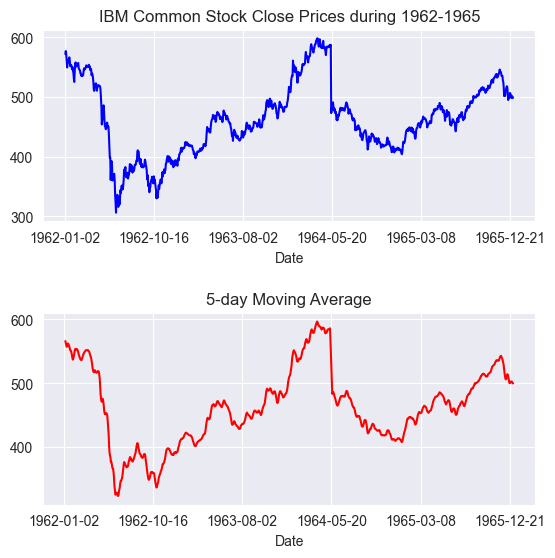

In [154]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(2,1,1)
ibm_df['Close_Price'].plot(ax=ax, color='b')
ax.set_title('IBM Common Stock Close Prices during 1962-1965')
ax = fig.add_subplot(2,1,2)
ibm_df['5-Day Moving Avg'].plot(ax=ax, color='r')
ax.set_title('5-day Moving Average')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [155]:
MA2 = ibm_df['Close_Price'].rolling(window=2).mean()
TwoXMA2 = MA2.rolling(window=2).mean()

MA4 = ibm_df['Close_Price'].rolling(window=4).mean()
TwoXMA4 = MA4.rolling(window=2).mean()

MA3 = ibm_df['Close_Price'].rolling(window=3).mean()
ThreeXMA3 = MA3.rolling(window=3).mean()

In [156]:
TwoXMA2 = MA2.dropna()
TwoXMA4 = MA4.dropna()
ThreeXMA3 = MA3.dropna()

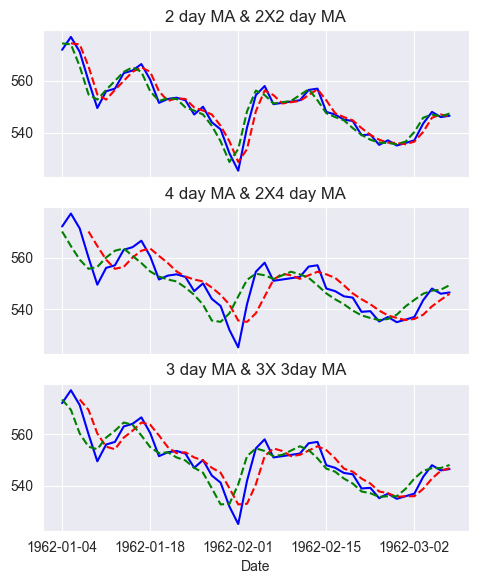

In [157]:
f, axarr = plt.subplots(3, sharex=True)
f.set_size_inches(5.5, 6.5)

ibm_df['Close_Price'].iloc[:45].plot(color='b', linestyle = '-', ax=axarr[0])
MA2.iloc[:45].plot(color='r', linestyle = '--', ax=axarr[0])
TwoXMA2.iloc[:45].plot(color='g', linestyle = '--', ax=axarr[0])
axarr[0].set_title('2 day MA & 2X2 day MA');

ibm_df['Close_Price'].iloc[:45].plot(color='b', linestyle = '-', ax=axarr[1])
MA4.iloc[:45].plot(color='r', linestyle = '--', ax=axarr[1])
TwoXMA4.iloc[:45].plot(color='g', linestyle = '--', ax=axarr[1])
axarr[1].set_title('4 day MA & 2X4 day MA');

ibm_df['Close_Price'].iloc[:45].plot(color='b', linestyle = '-', ax=axarr[2])
MA3.iloc[:45].plot(color='r', linestyle = '--', ax=axarr[2])
ThreeXMA3.iloc[:45].plot(color='g', linestyle = '--', ax=axarr[2])
axarr[2].set_title('3 day MA & 3X 3day MA');

## 1.32 Ajuste estacional mediante media móvil

In [158]:
import pandas as pd
from matplotlib import pyplot as plt

In [159]:
beer_df = pd.read_csv('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\quarterly-beer-production-in-aus-March 1956-June 1994.csv')
beer_df.index = beer_df['Quarter']

In [160]:
print('Shape of the dataframe:', beer_df.shape)
beer_df.head()

Shape of the dataframe: (155, 2)


,Quarter,Quarterly beer production in Australia: megalitres. March 1956 ? June 1994
Quarter,,
1956Q1,1956Q1,284.4
1956Q2,1956Q2,212.8
1956Q3,1956Q3,226.9
1956Q4,1956Q4,308.4
1957Q1,1957Q1,262.0


In [161]:
beer_df.rename(columns={'Quarterly beer production in Australia: megalitres. March 1956 ? June 1994':'Beer_Prod'},
               inplace=True)

In [162]:
missing = (pd.isnull(beer_df['Quarter'])) | (pd.isnull(beer_df['Beer_Prod']))
print('Number of rows with at least one missing values:', missing.sum())
beer_df = beer_df.loc[~missing, :]
print('Shape after removing missing values:', beer_df.shape)

Number of rows with at least one missing values: 1
Shape after removing missing values: (154, 2)


In [163]:
MA4 = beer_df['Beer_Prod'].rolling(window=4).mean()
TwoXMA4 = MA4.rolling(window=2).mean()
TwoXMA4 = TwoXMA4.loc[~pd.isnull(TwoXMA4)]

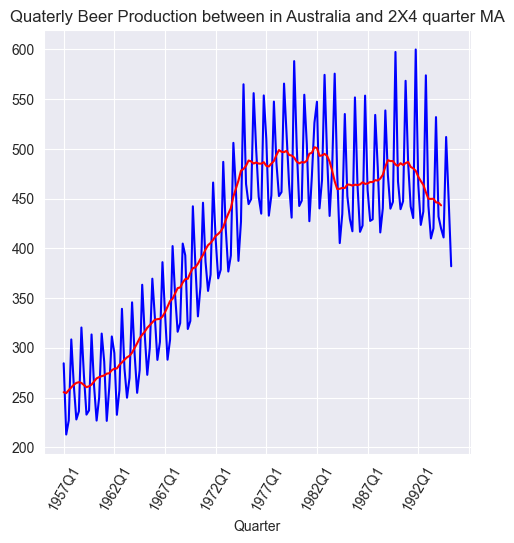

In [164]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
beer_df['Beer_Prod'].plot(ax=ax, color='b', linestyle='-')
TwoXMA4.plot(ax=ax, color='r', linestyle='-')
plt.xticks(rotation=60);
ax.set_title('Quaterly Beer Production between in Australia and 2X4 quarter MA');

In [165]:
residuals = beer_df['Beer_Prod']-TwoXMA4
residuals = residuals.loc[~pd.isnull(residuals)]

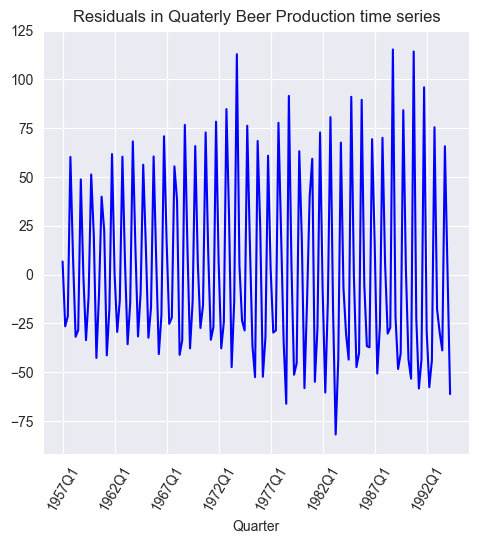

In [166]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
residuals.plot(ax=ax, color='b', linestyle='-')
plt.xticks(rotation=60);
ax.set_title('Residuals in Quaterly Beer Production time series');

In [167]:
from pandas.plotting import autocorrelation_plot

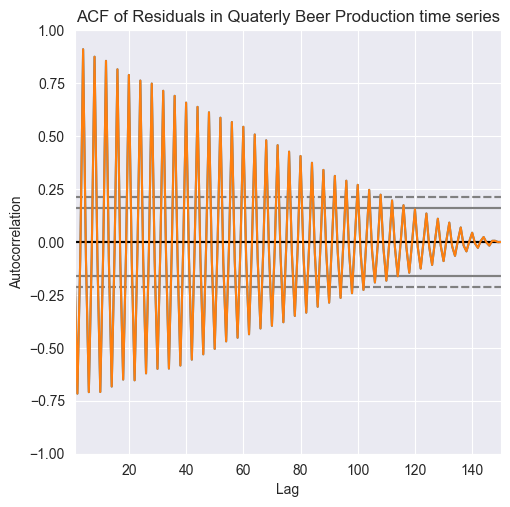

In [168]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
autocorrelation_plot(residuals, ax=ax)
ax.set_title('ACF of Residuals in Quaterly Beer Production time series');
autocorrelation_plot(residuals);

In [169]:
residuals_qtr_diff = np.log(residuals.diff(4))

In [170]:
residuals_qtr_diff = residuals_qtr_diff.loc[~pd.isnull(residuals_qtr_diff)]

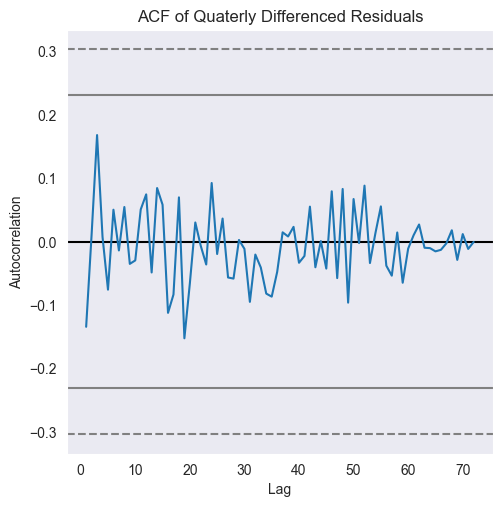

In [171]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
autocorrelation_plot(residuals_qtr_diff, ax=ax)
ax.set_title('ACF of Quaterly Differenced Residuals');

In [172]:
_, _, _, pval_monthly_mean = stattools.acf(residuals_qtr_diff,
                                           nlags=10, 
                                           qstat=True, 
                                           alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean<=0.05))

Null hypothesis is rejected for lags: (array([], dtype=int64),)


## 1.34 Descomposición de series temporales mediante medias móviles

In [174]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from matplotlib import pyplot as plt

In [175]:
air_miles = pd.read_csv('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\us-airlines-monthly-aircraft-miles-flown.csv')
air_miles.index = air_miles['Month']

In [176]:
print('Shape of the DataFrame:', air_miles.shape)
air_miles.head()

Shape of the DataFrame: (97, 2)


,Month,U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970
Month,,
1963-01,1963-01,6827.0
1963-02,1963-02,6178.0
1963-03,1963-03,7084.0
1963-04,1963-04,8162.0
1963-05,1963-05,8462.0


In [177]:
air_miles.rename(columns={'U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970': 'Air miles flown'}, 
                 inplace=True)
air_miles.head()

,Month,Air miles flown
Month,,
1963-01,1963-01,6827.0
1963-02,1963-02,6178.0
1963-03,1963-03,7084.0
1963-04,1963-04,8162.0
1963-05,1963-05,8462.0


In [178]:
missing = pd.isnull(air_miles['Air miles flown'])
print('Number of missing values found:', missing.sum())
air_miles = air_miles.loc[~missing, :]

Number of missing values found: 1


In [179]:
MA12 = air_miles['Air miles flown'].rolling(window=12).mean()
trendComp = MA12.rolling(window=2).mean()

In [180]:
residuals = air_miles['Air miles flown'] - trendComp

month = air_miles['Month'].map(lambda d: d[-2:])
monthwise_avg = residuals.groupby(by=month).aggregate(['mean'])
nb_years = 1970-1963+1

seasonalComp = np.array([monthwise_avg.values]*nb_years).reshape((12*nb_years,))

In [181]:
irr_var = air_miles['Air miles flown'] - trendComp - seasonalComp

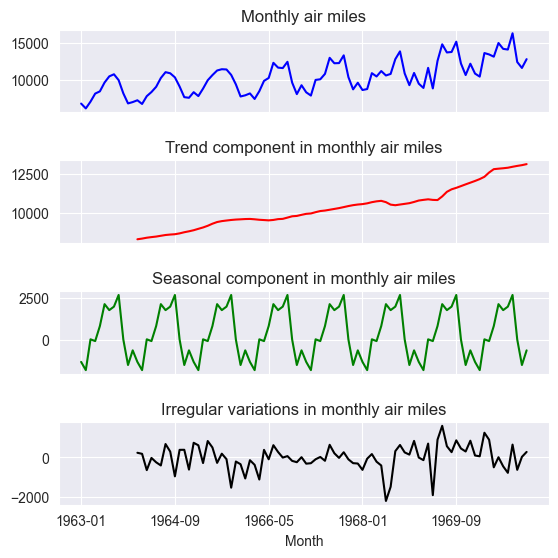

In [182]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

air_miles['Air miles flown'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly air miles')

pd.Series(data=trendComp, index=air_miles.index).plot(ax=axarr[1], color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly air miles')

pd.Series(data=seasonalComp, index=air_miles.index).plot(ax=axarr[2], color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly air miles')

pd.Series(data=irr_var, index=air_miles.index).plot(ax=axarr[3], color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly air miles')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [183]:
adf_result = stattools.adfuller(irr_var.loc[~pd.isnull(irr_var)], autolag='AIC')
print('p-val of the ADF test on irregular variations in air miles flown:', adf_result[1])

p-val of the ADF test on irregular variations in air miles flown: 0.06577411025730086


In [184]:
residuals = air_miles['Air miles flown'] / trendComp

In [185]:
month = air_miles['Month'].map(lambda d: d[-2:])
monthwise_avg = residuals.groupby(by=month).aggregate(['mean'])
nb_years = 1970-1963+1

seasonalComp = np.array([monthwise_avg.values]*nb_years).reshape((12*nb_years,))

In [186]:
irr_var = air_miles['Air miles flown'] / (trendComp * seasonalComp)

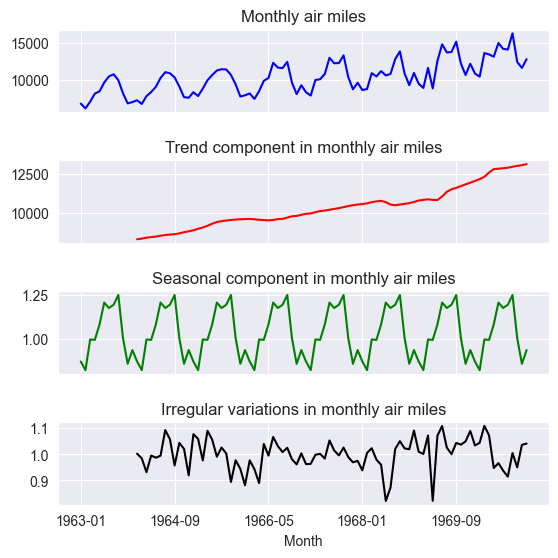

In [187]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

air_miles['Air miles flown'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly air miles')

pd.Series(data=trendComp, index=air_miles.index).plot(ax=axarr[1], color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly air miles')

pd.Series(data=seasonalComp, index=air_miles.index).plot(ax=axarr[2], color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly air miles')

pd.Series(data=irr_var, index=air_miles.index).plot(ax=axarr[3], color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly air miles')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [188]:
adf_result = stattools.adfuller(irr_var.loc[~pd.isnull(irr_var)], autolag='AIC')
print('p-val of the ADF test on irregular variations in air miles flown:', adf_result[1])

p-val of the ADF test on irregular variations in air miles flown: 0.00017645280908370881


## 1.35 Descomposición e series temporales mediante `statsmodels.tsa`

In [189]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from statsmodels.tsa import seasonal
from matplotlib import pyplot as plt

In [190]:
wisc_emp = pd.read_csv('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\wisconsin-employment-time-series.csv')
wisc_emp.index = wisc_emp['Month']

In [191]:
print('Shape of the DataFrame:', wisc_emp.shape)
wisc_emp.head(10)

Shape of the DataFrame: (178, 2)


,Month,Employment
Month,,
1961-01,1961-01,239.6
1961-02,1961-02,236.4
1961-03,1961-03,236.8
1961-04,1961-04,241.5
1961-05,1961-05,243.7
1961-06,1961-06,246.1
1961-07,1961-07,244.1
1961-08,1961-08,244.2
1961-09,1961-09,244.8


In [192]:
missing = (pd.isnull(wisc_emp['Employment'])) | (pd.isnull(wisc_emp['Month']))
print('Number of missing values found:', missing.sum())
wisc_emp = wisc_emp.loc[~missing, :]

Number of missing values found: 0


In [193]:
adf_result = stattools.adfuller(wisc_emp['Employment'], autolag='AIC')
print('p-val of the ADF test on irregular variations in employment data:', adf_result[1])

p-val of the ADF test on irregular variations in employment data: 0.9810000189539192


In [194]:
decompose_model = seasonal.seasonal_decompose(wisc_emp.Employment.tolist(), period=12, model='additive')

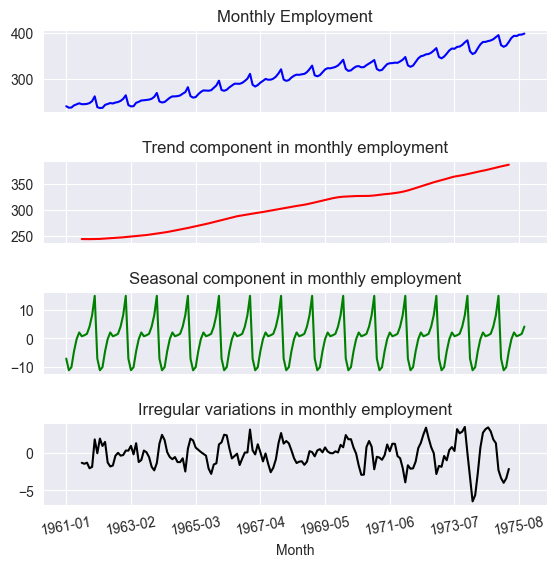

In [195]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

wisc_emp['Employment'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly Employment')

pd.Series(data=decompose_model.trend, index=wisc_emp.index).plot(color='r', linestyle='-', ax=axarr[1])
axarr[1].set_title('Trend component in monthly employment')

pd.Series(data=decompose_model.seasonal, index=wisc_emp.index).plot(color='g', linestyle='-', ax=axarr[2])
axarr[2].set_title('Seasonal component in monthly employment')

pd.Series(data=decompose_model.resid, index=wisc_emp.index).plot(color='k', linestyle='-', ax=axarr[3])
axarr[3].set_title('Irregular variations in monthly employment')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0);
plt.xticks(rotation=10);

In [196]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in employment data:', adf_result[1])

p-val of the ADF test on irregular variations in employment data: 0.006560931634641196


In [198]:
decompose_model = seasonal.seasonal_decompose(wisc_emp.Employment.tolist(), period=12, model='multiplicative')

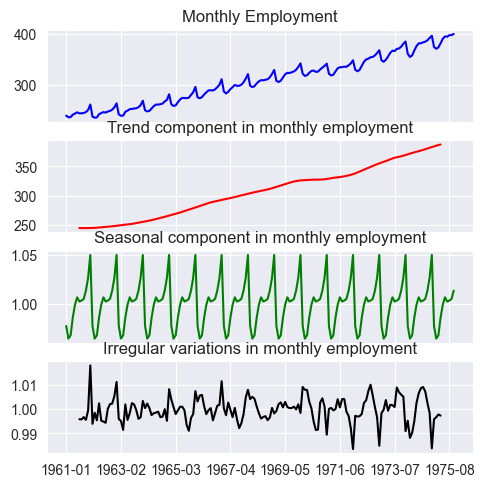

In [199]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

wisc_emp['Employment'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly Employment');

axarr[1].plot(decompose_model.trend, color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly employment');

axarr[2].plot(decompose_model.seasonal, color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly employment');

axarr[3].plot(decompose_model.resid, color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly employment');

In [200]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in employment data:', adf_result[1])

p-val of the ADF test on irregular variations in employment data: 0.0012347837267732101


# 2. **Análisis exploratorio de datos EDA**

- **Paper base:** Abdollahi, H. (2020). 
A novel hybrid model for forecasting crude oil price based on time series decomposition. 
*Applied Energy, 267*, 115035. 
https://doi.org/10.1016/j.apenergy.2020.115035

El artículo propone un modelo híbrido para la predicción del precio del petróleo WTI, basado en la descomposición de series de tiempo y la combinación de métodos econométricos y de inteligencia artificial.

La idea central es que el precio del petróleo presenta características complejas como no linealidad, alta volatilidad, cambios estructurales y dependencias temporales, las cuales no pueden ser capturadas adecuadamente por un solo modelo. Por ello, el autor utiliza una estrategia descomponiendo la serie en distintos componentes mediante CEEMD (Complete Ensemble Empirical Mode Decomposition).

Posteriormente:

- Los componentes no lineales se modelan con Support Vector Machine (SVM) optimizado con Particle Swarm Optimization (PSO).
- Los componentes volátiles se modelan con Markov-Switching GARCH (MS-GARCH), que captura cambios de régimen en la volatilidad.

Finalmente, las predicciones de cada componente se agregan para obtener el pronóstico total. Los resultados muestran que este enfoque híbrido supera a modelos tradicionales y a otros modelos híbridos, logrando mayor precisión en métricas como MAE, RMSE y MAPE.


## 2.1. Introducción y contexto

- **Objetivo del análisis:** El análisis exploratorio de datos constituye una fase preliminar esencial en el estudio de series de tiempo, dado que permite caracterizar la estructura de la información, identificar patrones temporales relevantes y detectar posibles problemas que puedan afectar el desempeño de los modelos de pronóstico. En particular, para una variable como el precio del petróleo Brent, el EDA resulta necesario debido a la elevada volatilidad que suele presentar esta serie y a su sensibilidad frente a choques económicos, financieros y geopolíticos. Por tanto, el propósito de esta etapa es examinar el comportamiento histórico de la serie, evaluar la existencia de tendencias, cambios en la variabilidad, observaciones atípicas y posibles quiebres estructurales, con el fin de establecer una base sólida para el posterior ejercicio de forecasting.

    Este análisis es especialmente importante para Colombia porque el petróleo sigue siendo una variable estratégica para el desempeño macroeconómico del país: influye sobre las exportaciones, las cuentas externas, los ingresos fiscales, las regalías y, en general, sobre la evolución de variables como el tipo de cambio, la inflación y la actividad económica. El Banco de la República ha documentado que los choques petroleros tienen efectos amplios sobre la economía colombiana, mientras que cifras recientes del DANE muestran que los combustibles y productos de industrias extractivas aún representan una fracción relevante del valor exportado por el país. A esto se suma que la ANH sigue reportando una producción petrolera estable en 2025-2026, lo que confirma que el comportamiento del precio internacional del crudo continúa siendo un determinante clave para evaluar riesgos y construir escenarios de pronóstico en Colombia.

- **Descripción de los datos:** La base de datos utilizada corresponde a la serie **DCOILBRENTEU** proporcionada por el **Federal reserve bank of ST. LOUIS** y la **U.S. Energy Administration**. Esta serie representa el precio del petróleo Brent. La información está organizada como una serie de tiempo con dos variables principales: la fecha de observación (`observation_date`) y el valor del precio del petróleo (`DCOILBRENTEU`).

    La frecuencia de los datos es diaria, lo que permite capturar con mayor detalle la dinámica de corto plazo del mercado petrolero y resulta apropiado para ejercicios de pronóstico en horizontes breves y medianos. La unidad de medida del precio corresponde a dólares estadounidenses por barril (US dollars per barrel), que es la convención estándar en los mercados internacionales de crudo.

    La serie disponible cubre el período comprendido entre 20 de mayo de 1987 y 23 de marzo de 2026, con un total de 10,134 observaciones. Esta amplitud temporal ofrece una ventaja importante para el análisis, ya que incluye distintos episodios relevantes del mercado energético internacional, como ciclos de auge y caída del precio del petróleo, crisis financieras globales, tensiones geopolíticas y choques recientes asociados a la recuperación pospandemia y a eventos internacionales que han afectado la oferta energética.

## 2.2 Análisis preliminar 

### 2.2.1. Inspección general 

In [201]:
import warnings
warnings.filterwarnings("ignore")

In [202]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

- Importamos los paquetes para manipulación y visualización de los datos 

In [203]:
sns.set_style("darkgrid")

- Agregamos una linea de estilo para las gráficas

In [211]:
data = pd.read_excel('C:\\Users\\cospi\\OneDrive\\Escritorio\\Msc_Economics\\Semestre_III\\Time_Series\\Trabajo_final\\DCOILBRENTEU.xlsx', sheet_name="Daily")
print('Column names:', data.columns)
print('No. of rows, columns:', data.shape)

Column names: Index(['observation_date', 'DCOILBRENTEU'], dtype='object')
No. of rows, columns: (10134, 2)


- Cargamos el DataSet que se compone de las columnas `observation_date`, `DCOILBRENTEU`
-  Este conjunto de datos cuenta con 10,134 observaciones y 2 variables

In [216]:
# Renombrar columnas para mayor claridad
data = data.rename(columns={
    data.columns[0]: "observation_date",
    data.columns[1]: "price"
})

In [217]:
data["observation_date"] = pd.to_datetime(data["observation_date"])
data = data.sort_values("observation_date").reset_index(drop=True)

print(data.head())
print(data.tail())

  observation_date  price
0       1987-05-20  18.63
1       1987-05-21  18.45
2       1987-05-22  18.55
3       1987-05-25  18.60
4       1987-05-26  18.63
      observation_date   price
10129       2026-03-17  108.39
10130       2026-03-18  118.09
10131       2026-03-19  111.05
10132       2026-03-20  118.42
10133       2026-03-23  103.79


- Convertimos la columna `observation_date` en formato fecha 
- Luego se imprimen las 5 primeras y las 5 ultimas observaciones 

In [221]:
# 1. Valores faltantes por columna
print("Valores faltantes por columna:")
print(data.isnull().sum())

Valores faltantes por columna:
observation_date      0
price               278
dtype: int64


- En este caso hay 278 filas con precios faltantes 

In [ ]:
data_ffill = data.copy() # Crear una copia del DataFrame original para realizar el forward fill
data_ffill["price"] = data_ffill["price"].ffill() # Rellenar los valores faltantes utilizando forward fill

print(data_ffill.isnull().sum())

observation_date    0
price               0
dtype: int64


- En este caso rellenamos los valores faltantes utilizando forward fill para mantener la originalidad de la serie, evitar eliminar observaciones y mantener la continuidad temporal

### 2.2.2. Estadisticas descriptivas

In [224]:
data["price"].describe() # Resumen estadístico de la columna 'price'

count    9856.000000
mean       50.920986
std        32.565810
min         9.100000
25%        19.530000
50%        45.875000
75%        74.560000
max       143.950000
Name: price, dtype: float64

- Para observar las estadisticas descriptivas utilizamos el `.describe`. Podemos observar que para la columna *price*, la media de los precios es de *50.9 dolares*, el dato minimo es *9.10 dolares*, el dato máximo *143.9 dolares*, la desviación estándar *32.5* y los percentiles *19.5, 45.8, 74.5* respectivamente

In [229]:
dispersion_metrics = {
    "Desviación estándar": data["price"].std(), # Desviación estándar de la columna 'price'
    "Varianza": data["price"].var(), # Varianza de la columna 'price' 
    "Rango": data["price"].max() - data["price"].min(), # Rango de la columna 'price' (máximo - mínimo)
    "Q1": data["price"].quantile(0.25), # Primer cuartil (25%) de la columna 'price'
    "Q3": data["price"].quantile(0.75), # Tercer cuartil (75%) de la columna 'price'
    "IQR": data["price"].quantile(0.75) - data["price"].quantile(0.25) # Rango intercuartílico (IQR) de la columna 'price' (Q3 - Q1)
}

for k, v in dispersion_metrics.items():
    print(f"{k}: {v:.2f}")

Desviación estándar: 32.57
Varianza: 1060.53
Rango: 134.85
Q1: 19.53
Q3: 74.56
IQR: 55.03


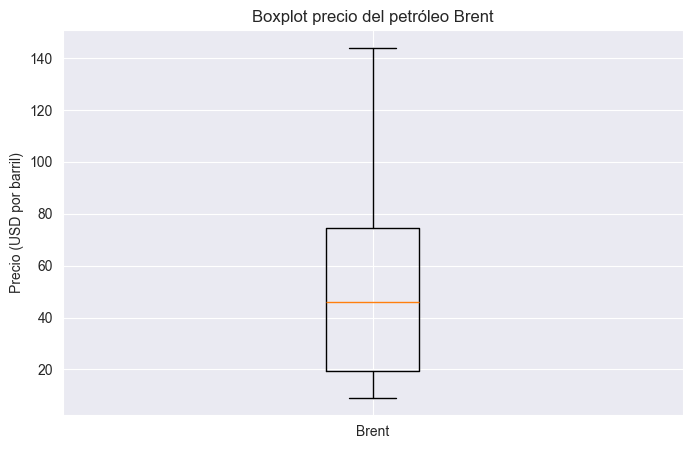

In [233]:
plt.figure(figsize=(8,5))
plt.boxplot(data["price"].dropna(), vert=True, labels=["Brent"])
plt.title("Boxplot precio del petróleo Brent")
plt.ylabel("Precio (USD por barril)")
plt.show()

- La mediana de la serie se ubica alrededor de *45.88 dólares* por barril, mientras que el *50%* central de las observaciones se encuentra entre *19.53* y *74.56 dólares*, lo que da lugar a un rango intercuartílico de *55.03*. Esta amplitud sugiere una variabilidad considerable en los precios. Asimismo, el rango total de la serie, igual a *134.85 dólares*, y la desviación estándar de *32.57* refuerzan la evidencia de una alta dispersión, consistente con la naturaleza volátil del mercado internacional del petróleo.

## 2.3. Visualización de la serie 

### 2.3.1. Visualización temporal

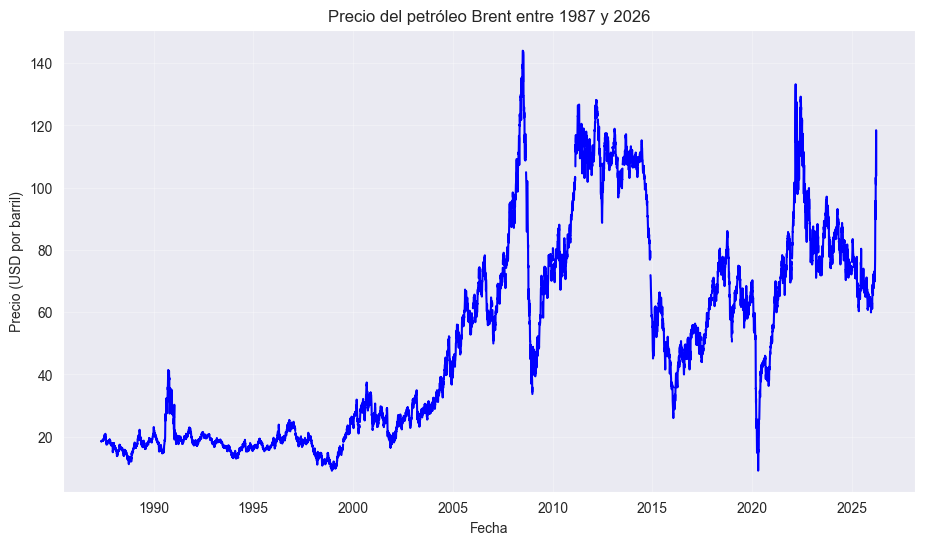

In [241]:
plt.figure(figsize=(11, 6))
plt.plot(data["observation_date"], data["price"], color="b")
plt.title("Precio del petróleo Brent entre 1987 y 2026")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD por barril)")
plt.grid(True, alpha=0.3)
plt.show()

- La serie presenta una marcada variabilidad temporal, con episodios de crecimiento pronunciado, caídas abruptas y periodos de elevada volatilidad.

### 2.3.2. Análisis de componentes

- Para dividir la serie en componentes de tendencia, estacionalidad y residuales compararemos la descomposición clásica aditiva y multiplicativa

In [ ]:
from statsmodels.tsa import stattools # Importar la función 'stattools' del módulo 'tsa' de la biblioteca 'statsmodels'
from statsmodels.tsa import seasonal # Importar la función 'seasonal' del módulo 'tsa' de la biblioteca 'statsmodels'


In [245]:
adf_result = stattools.adfuller(data_ffill['price'], autolag='AIC')
print('p-val of the ADF test on irregular variations in price data:', adf_result[1])

p-val of the ADF test on irregular variations in price data: 0.25899334627397724


- Como el p-value es mayor que 0.05 no se rechaza la hipotesis nula por lo tanto la serie es no estacionaria

In [248]:
decompose_model = seasonal.seasonal_decompose(data_ffill['price'].tolist(), period=365, model='additive')

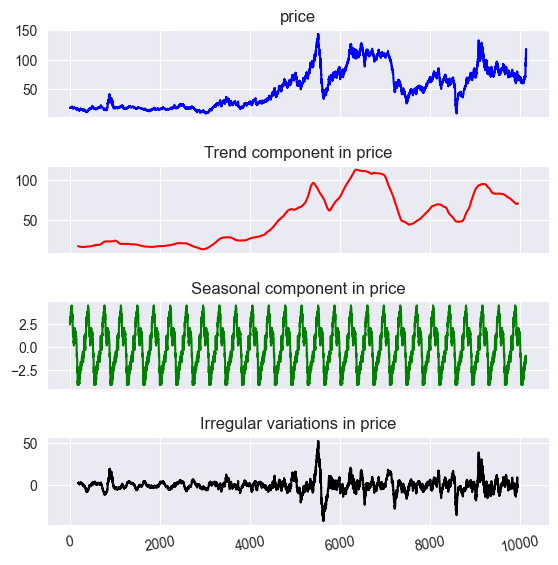

In [249]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

data_ffill['price'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('price')

pd.Series(data=decompose_model.trend, index=data_ffill.index).plot(color='r', linestyle='-', ax=axarr[1])
axarr[1].set_title('Trend component in price')

pd.Series(data=decompose_model.seasonal, index=data_ffill.index).plot(color='g', linestyle='-', ax=axarr[2])
axarr[2].set_title('Seasonal component in price')

pd.Series(data=decompose_model.resid, index=data_ffill.index).plot(color='k', linestyle='-', ax=axarr[3])
axarr[3].set_title('Irregular variations in price')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0);
plt.xticks(rotation=10);

In [250]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in price data:', adf_result[1])

p-val of the ADF test on irregular variations in price data: 7.144086464464505e-17


- Al ejecutar la prueba **ADF** sobre los residuos aditivos, obtenemos un p-value mucho menor a 0.05 

In [251]:
decompose_model = seasonal.seasonal_decompose(data_ffill['price'].tolist(), period=365, model='multiplicative')

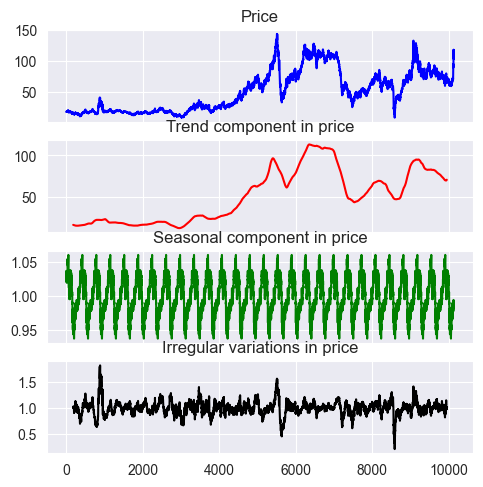

In [252]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

data_ffill['price'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Price');

axarr[1].plot(decompose_model.trend, color='r', linestyle='-')
axarr[1].set_title('Trend component in price');

axarr[2].plot(decompose_model.seasonal, color='g', linestyle='-')
axarr[2].set_title('Seasonal component in price');

axarr[3].plot(decompose_model.resid, color='k', linestyle='-')
axarr[3].set_title('Irregular variations in price');

In [253]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in price data:', adf_result[1])

p-val of the ADF test on irregular variations in price data: 2.0164847259688715e-18


- Con la descomposición multiplicativa, la prueba **ADF** sobre los residuos tiene un p-valor mucho menor que con la aditiva, por lo tanto podemos rechazar la hipotesis nula y concluir que los residuos corresponden a una serie estacionaria 

### 2.3.3. Detección de anomalías

In [ ]:
q1 = data_ffill["price"].quantile(0.25) # Calcular el primer cuartil (Q1) de la columna 'price' utilizando el método 'quantile' de pandas
q3 = data_ffill["price"].quantile(0.75) # Calcular el tercer cuartil (Q3) de la columna 'price' utilizando el método 'quantile' de pandas
iqr = q3 - q1 # Calcular el rango intercuartílico (IQR)

lower_bound = q1 - 1.5 * iqr 
upper_bound = q3 + 1.5 * iqr

outliers = data_ffill[(data_ffill["price"] < lower_bound) | (data_ffill["price"] > upper_bound)] # Identificar los valores atípicos en la columna 'price' utilizando los límites inferior y superior calculados anteriormente. Se seleccionan las filas del DataFrame 'data_ffill' donde el valor de 'price' es menor que el límite inferior o mayor que el límite superior, y se almacenan en el DataFrame 'outliers'.

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", lower_bound)
print("Límite superior:", upper_bound)
print("Número de valores atípicos:", outliers.shape[0])

print(outliers.head())

Q1: 19.515
Q3: 74.68
IQR: 55.165000000000006
Límite inferior: -63.2325
Límite superior: 157.4275
Número de valores atípicos: 0
Empty DataFrame
Columns: [observation_date, price]
Index: []


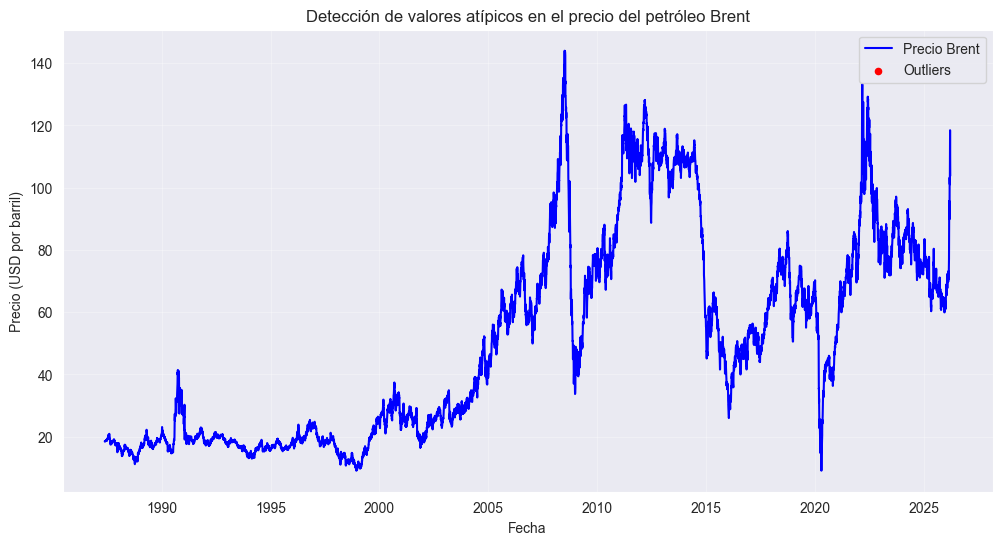

In [260]:
plt.figure(figsize=(12,6))
plt.plot(data_ffill["observation_date"], data_ffill["price"], label="Precio Brent", color="blue")
plt.scatter(outliers["observation_date"], outliers["price"], color="red", label="Outliers", s=20)

plt.title("Detección de valores atípicos en el precio del petróleo Brent")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD por barril)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

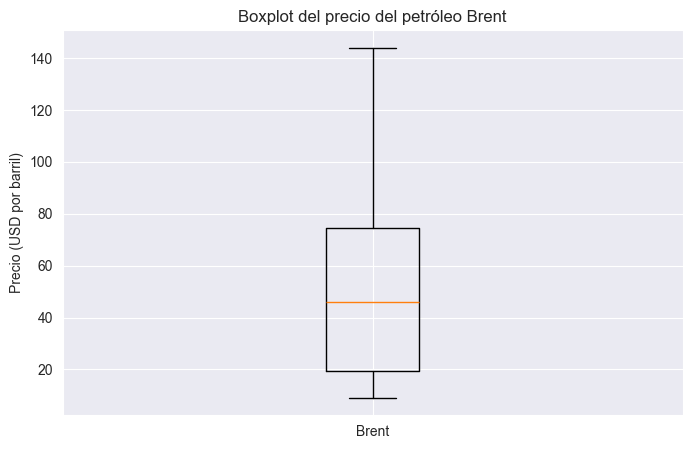

In [261]:
plt.figure(figsize=(8,5))
plt.boxplot(data_ffill["price"].dropna(), labels=["Brent"])
plt.title("Boxplot del precio del petróleo Brent")
plt.ylabel("Precio (USD por barril)")
plt.show()

- Como se puede observar en los distintos gráficos (Gráfico temporal y Boxplot) y a partir del rango intercuartílico, en la serie no se detectan datos atípicos u outliers

## 2.4. Estacionalidad y periodicidad

### 2.4.1. Análisis de patrones recurrentes 

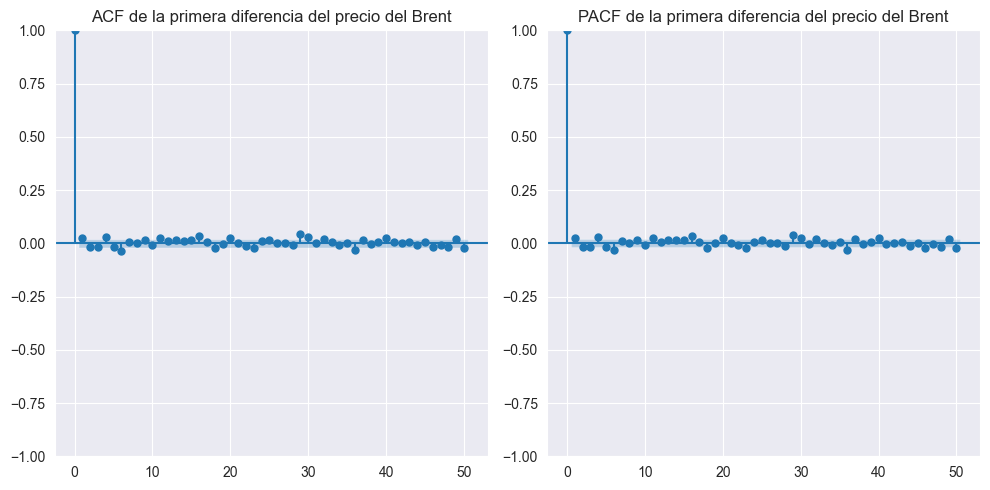

In [266]:
# Primera diferencia
data_ffill["price_diff"] = data_ffill["price"].diff()

# Elegir serie para ACF/PACF
serie = data_ffill["price_diff"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_acf(serie, lags=50, ax=axes[0])
axes[0].set_title("ACF de la primera diferencia del precio del Brent")

plot_pacf(serie, lags=50, ax=axes[1], method="ywm")
axes[1].set_title("PACF de la primera diferencia del precio del Brent")

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

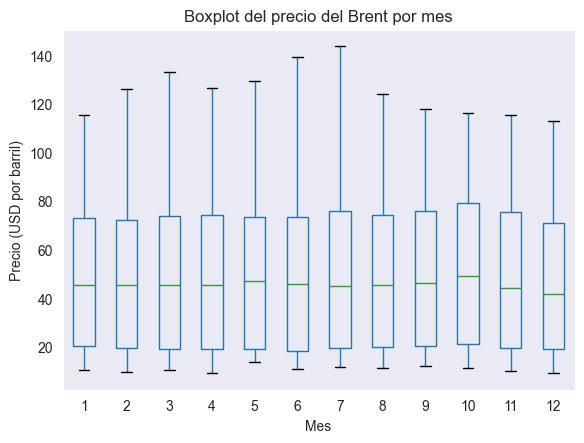

In [267]:
data_ffill["month"] = data_ffill["observation_date"].dt.month

plt.figure(figsize=(12, 6))
data_ffill.boxplot(column="price", by="month", grid=False)
plt.title("Boxplot del precio del Brent por mes")
plt.suptitle("")
plt.xlabel("Mes")
plt.ylabel("Precio (USD por barril)")
plt.show()

<Figure size 2000x1000 with 0 Axes>

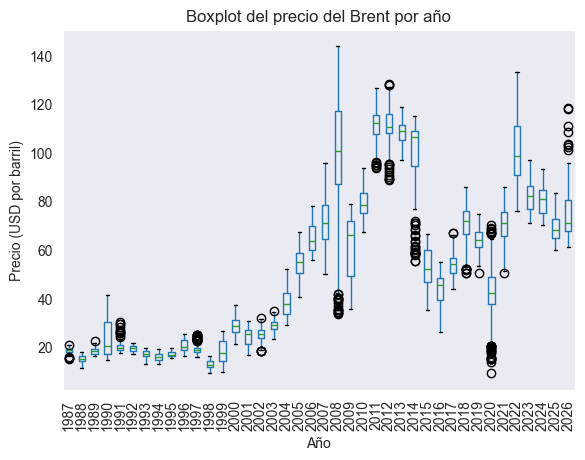

In [272]:
data_ffill["year"] = data_ffill["observation_date"].dt.year

plt.figure(figsize=(20, 10))
data_ffill.boxplot(column="price", by="year", grid=False, rot=90)
plt.title("Boxplot del precio del Brent por año")
plt.suptitle("")
plt.xlabel("Año")
plt.ylabel("Precio (USD por barril)")
plt.show()

<Figure size 1000x600 with 0 Axes>

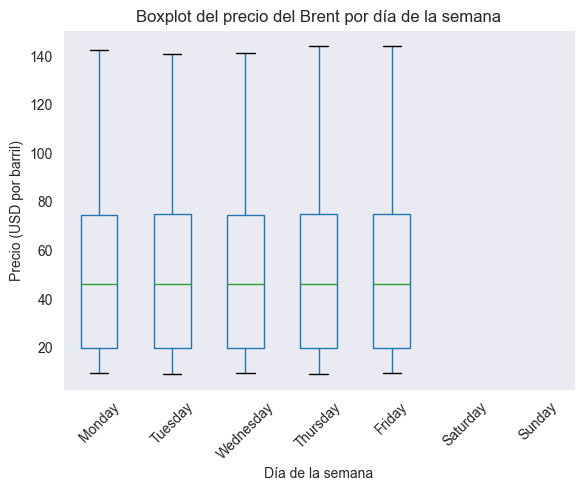

In [269]:
data_ffill["day_name"] = data_ffill["observation_date"].dt.day_name()

orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
data_ffill["day_name"] = pd.Categorical(data_ffill["day_name"], categories=orden_dias, ordered=True)

plt.figure(figsize=(10, 6))
data_ffill.boxplot(column="price", by="day_name", grid=False)
plt.title("Boxplot del precio del Brent por día de la semana")
plt.suptitle("")
plt.xlabel("Día de la semana")
plt.ylabel("Precio (USD por barril)")
plt.xticks(rotation=45)
plt.show()

- Las funciones de autocorrelación y autocorrelación parcial **ACF** y **PACF** muestran que la mayoria de los coeficientes son cercanos a cero. Por otro lado los diagramas de caja muestran que los cambios son más fuertes entre años mientras que por mes y por día no existen diferencias significativas

### 2.4.2. Transformación del dominio del tiempo

In [ ]:
data_ffill["observation_date"] = pd.to_datetime(data_ffill["observation_date"]) # Asegurarse de que la columna 'observation_date' esté en formato datetime
data_ffill = data_ffill.set_index("observation_date") # Establecer la columna 'observation_date' como índice del DataFrame

monthly_data = data_ffill["price"].resample("M").mean() # Resamplear la serie temporal a frecuencia mensual y calcular la media de 'price' para cada mes

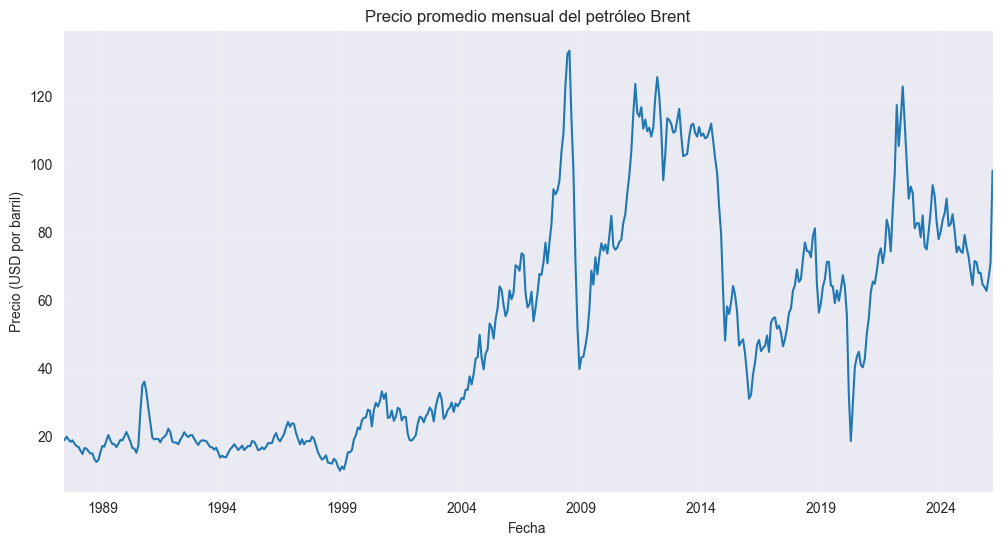

In [276]:
plt.figure(figsize=(12,6))
monthly_data.plot()
plt.title("Precio promedio mensual del petróleo Brent")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD por barril)")
plt.grid(True, alpha=0.3)
plt.show()

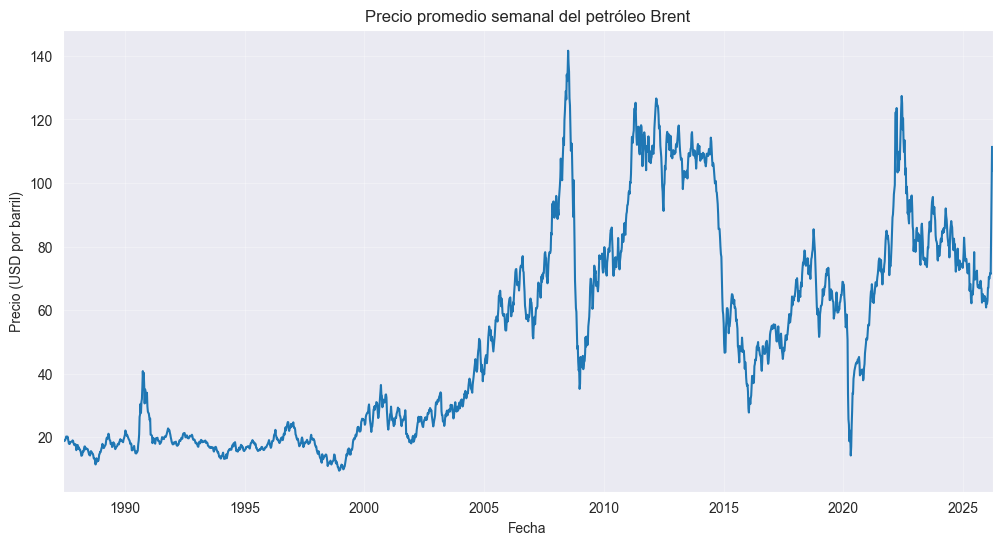

In [277]:
weekly_data = data_ffill["price"].resample("W").mean()

plt.figure(figsize=(12,6))
weekly_data.plot()
plt.title("Precio promedio semanal del petróleo Brent")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD por barril)")
plt.grid(True, alpha=0.3)
plt.show()

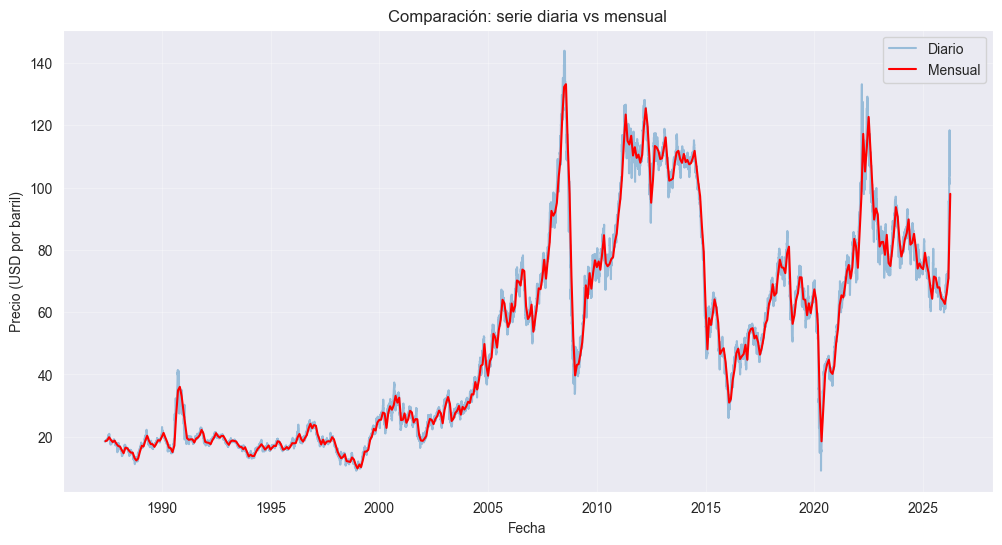

In [278]:
plt.figure(figsize=(12,6))

plt.plot(data_ffill.index, data_ffill["price"], alpha=0.4, label="Diario")
plt.plot(monthly_data.index, monthly_data, color="red", label="Mensual")

plt.title("Comparación: serie diaria vs mensual")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD por barril)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

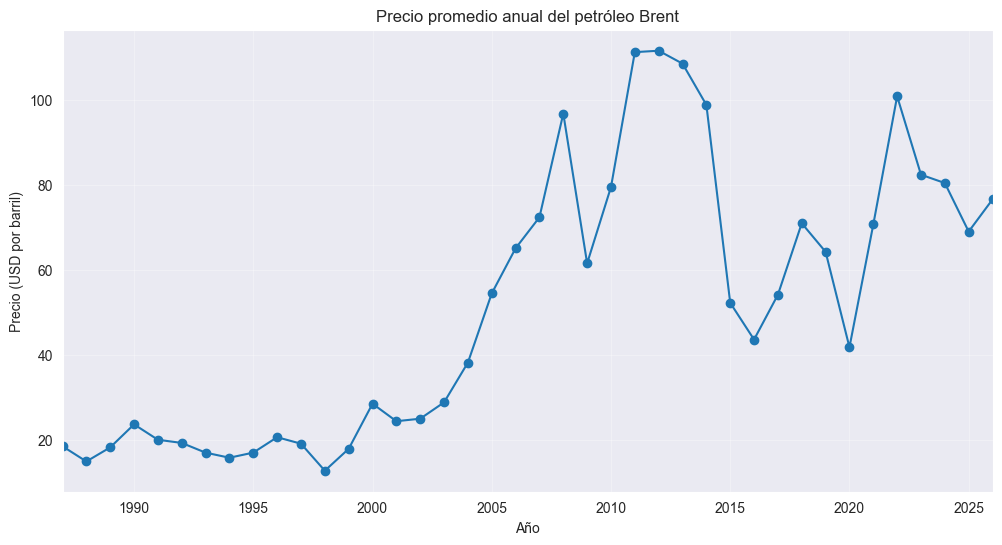

In [279]:
yearly_data = data_ffill["price"].resample("Y").mean()

plt.figure(figsize=(12,6))
yearly_data.plot(marker="o")
plt.title("Precio promedio anual del petróleo Brent")
plt.xlabel("Año")
plt.ylabel("Precio (USD por barril)")
plt.grid(True, alpha=0.3)
plt.show()

- Con el fin de analizar la serie del precio del petróleo Brent a diferentes niveles de agregación, se realizó una transformación del dominio del tiempo mediante la agrupación de los datos en frecuencias **semanal, mensual y anual**.

    Los resultados muestran que, a medida que se incrementa el nivel de agregación temporal, la serie presenta un **comportamiento más suave y una tendencia más claramente definida**. En particular, la *serie mensual* permite identificar con mayor claridad los ciclos del mercado petrolero, mientras que la *serie anual* resalta cambios estructurales asociados a eventos macroeconómicos y geopolíticos.

    Por otro lado, la comparación entre la serie diaria y la serie mensual evidencia que gran parte de la variabilidad observada a alta frecuencia corresponde a fluctuaciones de corto plazo

## 2.5 Análisis de tendencia

- Aplicando una *DES* vista en clase

In [284]:
def firstsmooth(y, lambda_, start=None):
    ytilde = y.copy()
    if start is None:
        start = y[0]
    ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
    for i in range(1, len(y)):
        ytilde[i] = lambda_ * y[i] + (1 - lambda_) * ytilde[i - 1]
    return ytilde

In [285]:
cpi_smooth1 = firstsmooth(y=data_ffill["price"], lambda_=0.3)
cpi_smooth2 = firstsmooth(y=cpi_smooth1, lambda_=0.3)

In [286]:
cpi_hat = 2 * cpi_smooth1 - cpi_smooth2

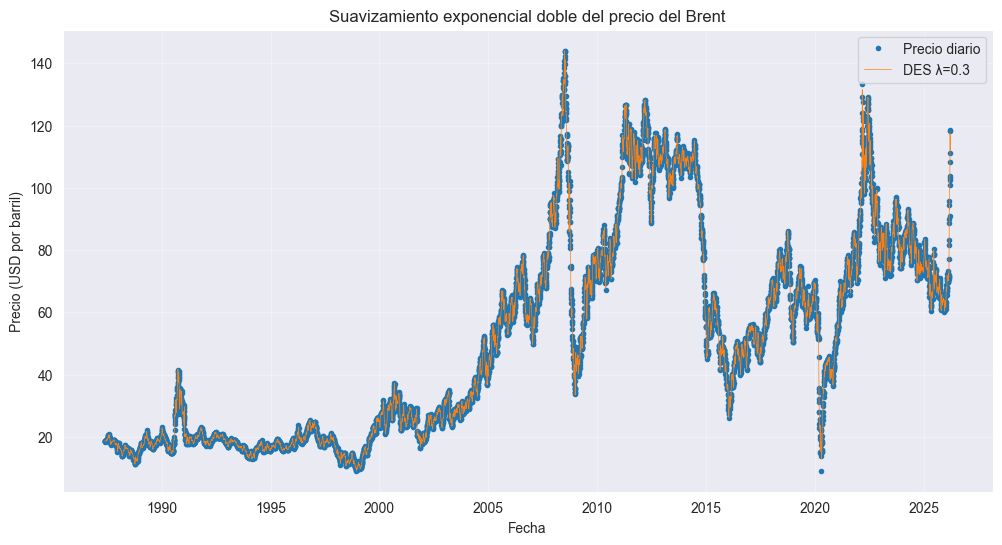

In [305]:
plt.figure(figsize=(12,6))

# Serie original
plt.plot(data_ffill.index, data_ffill["price"],
         marker='o', linestyle='', markersize=3, label='Precio diario')

# Serie suavizada (DES)
plt.plot(data_ffill.index, cpi_hat,
         label='DES λ=0.3', linewidth=0.5)

plt.xlabel('Fecha')
plt.ylabel('Precio (USD por barril)')
plt.title('Suavizamiento exponencial doble del precio del Brent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- La figura muestra la serie diaria del precio del petróleo Brent junto con su suavizamiento exponencial doble. Mientras la serie original refleja una alta volatilidad y numerosos movimientos de corto plazo, la curva suavizada permite identificar con mayor claridad la tendencia subyacente y los principales ciclos del mercado petrolero a lo largo del periodo analizado.

## 2.6. Estabilidad de la serie

In [310]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

In [309]:
adf_level = adfuller(data_ffill["price"].dropna(), autolag="AIC")
print("ADF en niveles")
print(f"Estadístico: {adf_level[0]:.4f}")
print(f"p-valor: {adf_level[1]:.6f}")

ADF en niveles
Estadístico: -2.0646
p-valor: 0.258993


In [312]:
kpss_level = kpss(data_ffill["price"].dropna(), regression="c", nlags="auto")
print("KPSS en niveles")
print(f"Estadístico: {kpss_level[0]:.4f}")
print(f"p-valor: {kpss_level[1]:.6f}")

KPSS en niveles
Estadístico: 10.3732
p-valor: 0.010000


In [ ]:
serie = data_ffill["price"].dropna().copy() # Crear una copia de la serie de precios sin valores nulos para evitar modificar el DataFrame original

n_groups = 5
group_size = len(serie) // n_groups

subsample_stats = []

for i in range(n_groups):
    start = i * group_size
    end = (i + 1) * group_size if i < n_groups - 1 else len(serie)  # Asegurar que el último grupo incluya cualquier elemento restante
    sub = serie.iloc[start:end]
    
    subsample_stats.append({
        "Submuestra": f"Bloque {i+1}",
        "Fecha inicio": sub.index.min(),
        "Fecha fin": sub.index.max(),
        "Media": sub.mean(),
        "Varianza": sub.var()
    })

subsample_df = pd.DataFrame(subsample_stats)
print(subsample_df)

  Submuestra Fecha inicio  Fecha fin      Media    Varianza
0   Bloque 1   1987-05-20 1995-02-22  18.415834   16.185591
1   Bloque 2   1995-02-23 2002-11-28  20.665656   31.185250
2   Bloque 3   2002-11-29 2010-09-03  60.831851  588.204296
3   Bloque 4   2010-09-06 2018-06-11  82.297897  829.067256
4   Bloque 5   2018-06-12 2026-03-23  72.834463  333.723895


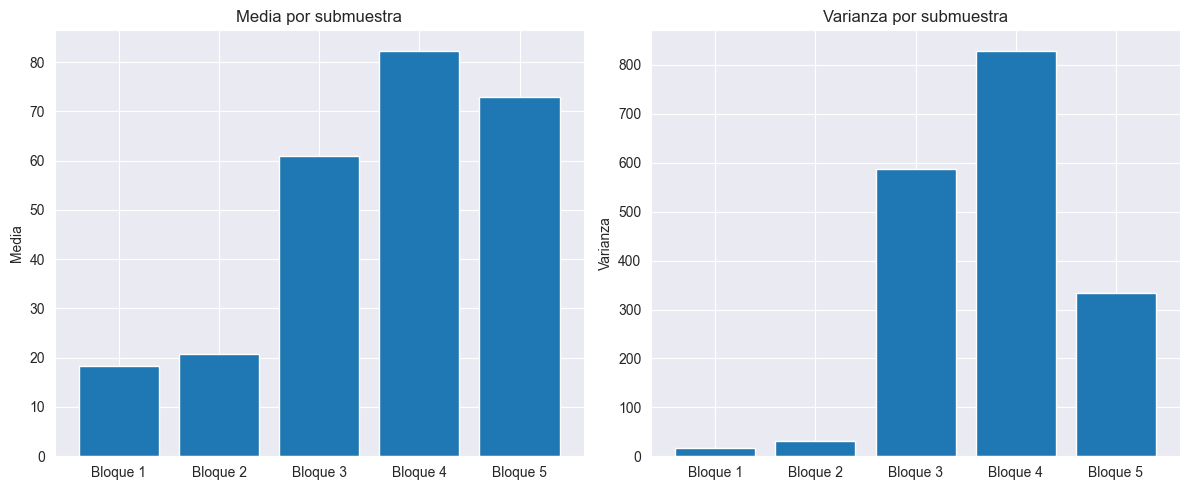

In [314]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(subsample_df["Submuestra"], subsample_df["Media"])
axes[0].set_title("Media por submuestra")
axes[0].set_ylabel("Media")

axes[1].bar(subsample_df["Submuestra"], subsample_df["Varianza"])
axes[1].set_title("Varianza por submuestra")
axes[1].set_ylabel("Varianza")

plt.tight_layout()
plt.show()

- Para evaluar la estacionariedad de la serie del precio del petróleo Brent, se aplicaron las pruebas de Dickey-Fuller aumentada (ADF) y KPSS. En la prueba ADF, cuyo objetivo es contrastar la presencia de una raíz unitaria, se obtuvo un p-valor de 0.258993, lo que impide rechazar la hipótesis nula de no estacionariedad. Por su parte, la prueba KPSS, cuya hipótesis nula corresponde a la estacionariedad de la serie, arrojó un p-valor de 0.01, lo que permite rechazar dicha hipótesis. En conjunto, ambas pruebas coinciden en indicar que la serie en niveles no es estacionaria.

- Por otro lado, con el fin de complementar las pruebas estadísticas de estacionariedad, se analizó la evolución de la media y la varianza en diferentes submuestras de la serie del precio del petróleo Brent. Los resultados muestran cambios significativos en ambas métricas a lo largo del tiempo. En particular, la media presenta un incremento sustancial entre los primeros y los bloques intermedios, seguido de una ligera reducción en el periodo final. Por su parte, la varianza evidencia un aumento pronunciado, alcanzando su punto máximo en las submuestras centrales, lo que indica episodios de alta volatilidad. Estos resultados confirman que la serie no mantiene una media ni una varianza constante en el tiempo, lo cual constituye evidencia clara de no estacionariedad.

### 2.6.2. Transformaciones de datos

In [ ]:
data_ffill["price_diff"] = data_ffill["price"].diff() # Calcular la primera diferencia de la columna 'price' y almacenarla en una nueva columna 'price_diff' del DataFrame 'data_ffill'. La función 'diff()' calcula la diferencia entre cada valor y el valor anterior en la serie temporal.

print(data_ffill[["price", "price_diff"]].head())

                  price  price_diff
observation_date                   
1987-05-20        18.63         NaN
1987-05-21        18.45       -0.18
1987-05-22        18.55        0.10
1987-05-25        18.60        0.05
1987-05-26        18.63        0.03


In [ ]:
data_ffill["log_diff"] = data_ffill["log_price"].diff() # Calcular la primera diferencia de la columna 'log_price' y almacenarla en una nueva columna 'log_diff' del DataFrame 'data_ffill'. La función 'diff()' calcula la diferencia entre cada valor y el valor anterior en la serie temporal.

print(data_ffill[["log_price", "log_diff"]].head())

                  log_price  log_diff
observation_date                     
1987-05-20         2.924773       NaN
1987-05-21         2.915064 -0.009709
1987-05-22         2.920470  0.005405
1987-05-25         2.923162  0.002692
1987-05-26         2.924773  0.001612


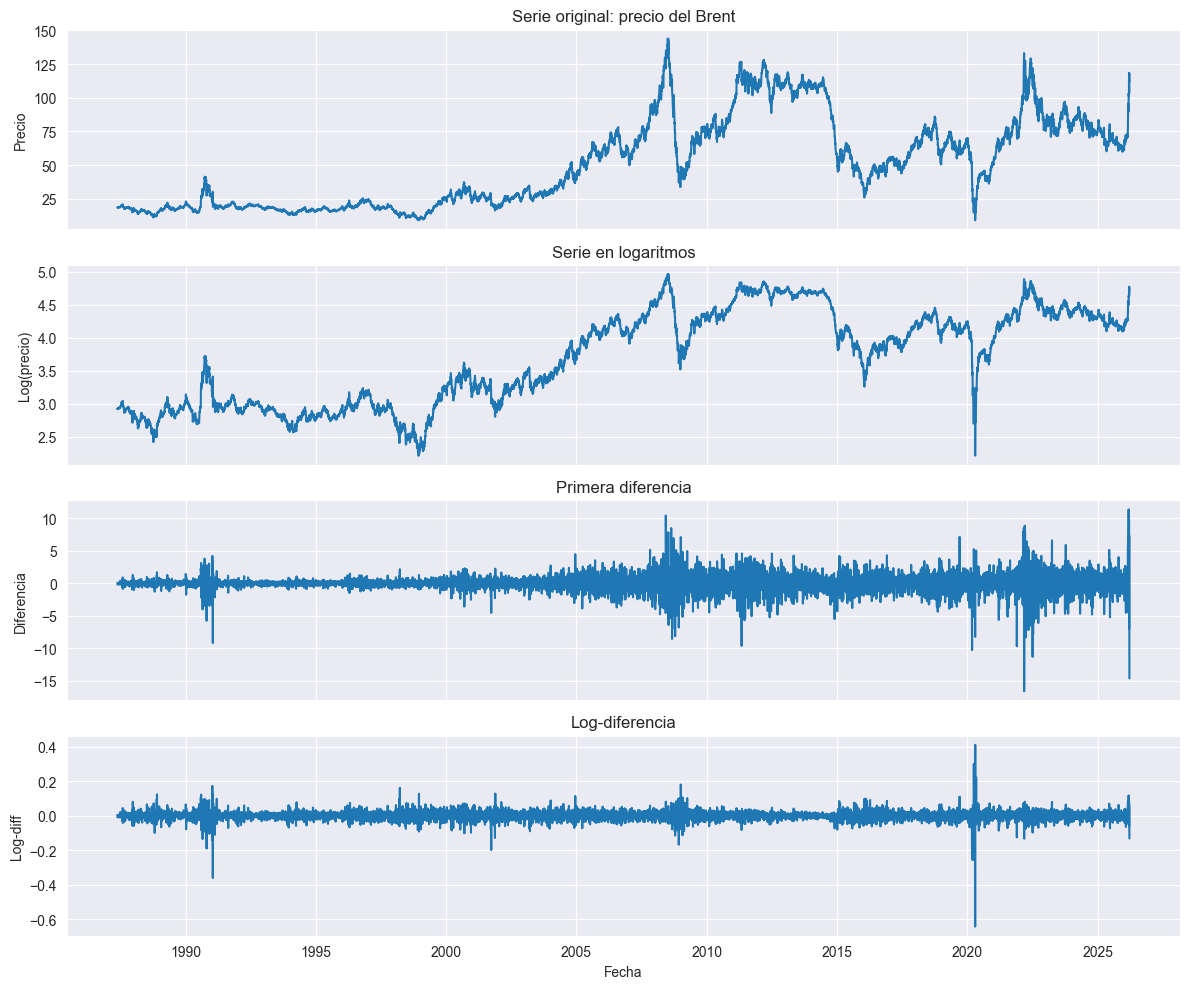

In [318]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(data_ffill.index, data_ffill["price"])
axes[0].set_title("Serie original: precio del Brent")
axes[0].set_ylabel("Precio")

axes[1].plot(data_ffill.index, data_ffill["log_price"])
axes[1].set_title("Serie en logaritmos")
axes[1].set_ylabel("Log(precio)")

axes[2].plot(data_ffill.index, data_ffill["price_diff"])
axes[2].set_title("Primera diferencia")
axes[2].set_ylabel("Diferencia")

axes[3].plot(data_ffill.index, data_ffill["log_diff"])
axes[3].set_title("Log-diferencia")
axes[3].set_ylabel("Log-diff")
axes[3].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

- Dado que la serie del precio del petróleo Brent presenta evidencia de no estacionariedad en niveles, se aplicaron distintas transformaciones con el objetivo de estabilizar su comportamiento y facilitar la modelación econométrica. En primer lugar, se utilizó la transformación logarítmica, la cual reduce la escala de la serie y permite interpretar los cambios en términos relativos. Posteriormente, se calculó la primera diferencia, con el fin de eliminar la tendencia estocástica presente en la serie original. Los resultados sugieren que tanto la primera diferencia como la log-diferencia generan series con propiedades más estables en el tiempo, en contraste con la serie original en niveles.

## 2.7. Análisis multivariado (No aplica)

## 2.8. Identificación de ciclos y frecuencia

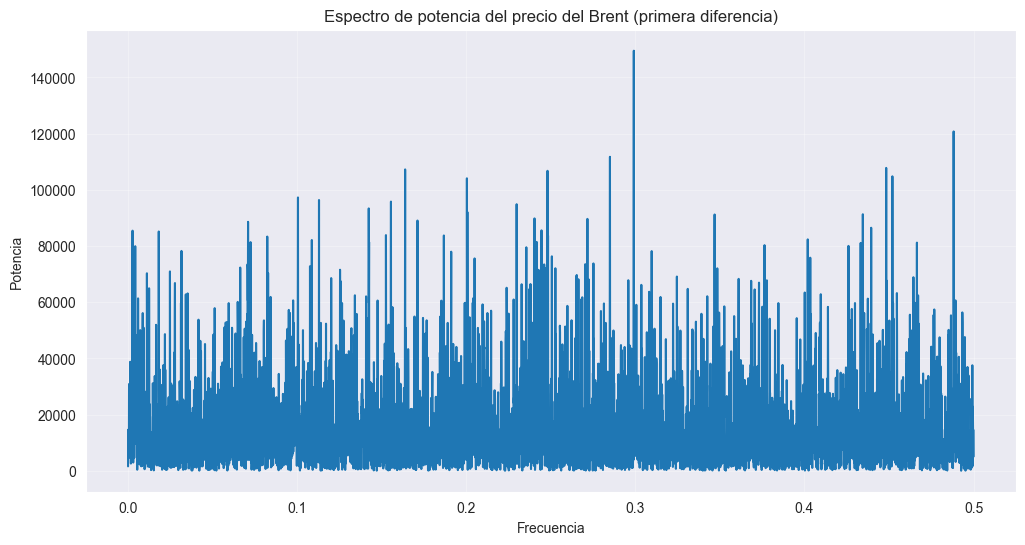

In [319]:

data_ffill["price_diff"] = data_ffill["price"].diff()
serie = data_ffill["price_diff"].dropna()

fft_vals = np.fft.fft(serie.values) # Calcular la Transformada Rápida de Fourier (FFT) de la serie de primera diferencia del precio del Brent. La función np.fft.fft toma como entrada los valores de la serie y devuelve un array de números complejos que representan las amplitudes de las frecuencias presentes en la serie.
fft_freq = np.fft.fftfreq(len(serie), d=1)  # d=1 porque la frecuencia es diaria


positive_freqs = fft_freq > 0 # Identificar las frecuencias positivas en el array de frecuencias. La función np.fft.fftfreq devuelve un array de frecuencias que incluye tanto frecuencias positivas como negativas. En este caso, se seleccionan solo las frecuencias positivas para analizar el espectro de potencia.
freqs = fft_freq[positive_freqs] # Obtener las frecuencias correspondientes a las frecuencias positivas. Se utiliza el array de frecuencias generado por np.fft.fftfreq y se seleccionan solo las frecuencias que corresponden a las frecuencias positivas identificadas en el paso anterior.
power = np.abs(fft_vals[positive_freqs])**2 # Calcular el espectro de potencia para las frecuencias positivas. El espectro de potencia se obtiene tomando el valor absoluto de los coeficientes de la FFT correspondientes a las frecuencias positivas y elevándolos al cuadrado. Esto proporciona una medida de la cantidad de energía presente en cada frecuencia.

# Graficar el espectro de potencia
plt.figure(figsize=(12,6))
plt.plot(freqs, power)
plt.title("Espectro de potencia del precio del Brent (primera diferencia)")
plt.xlabel("Frecuencia")
plt.ylabel("Potencia")
plt.grid(True, alpha=0.3)
plt.show()

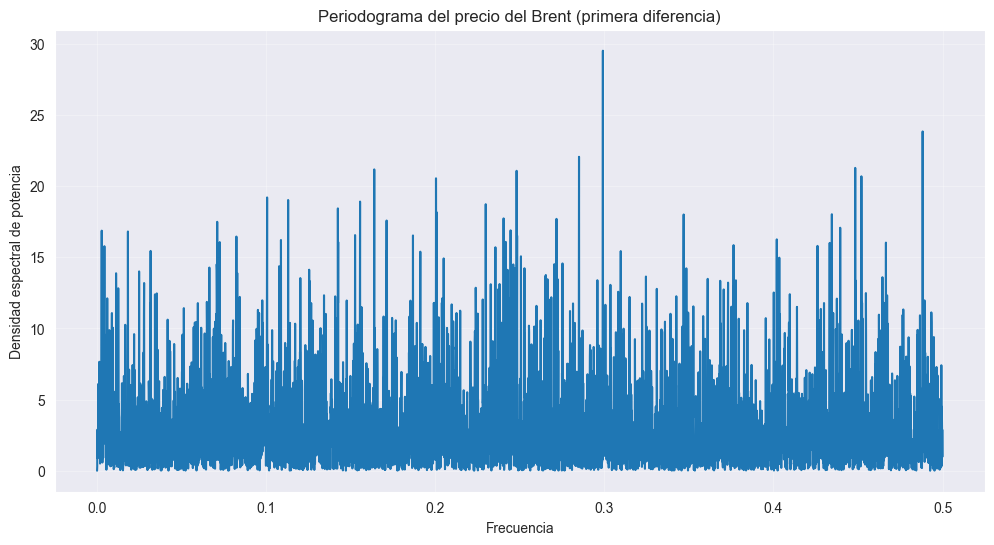

In [320]:
from scipy.signal import periodogram

freqs_p, power_p = periodogram(serie.values, fs=1)  # fs=1 observación por día

plt.figure(figsize=(12,6))
plt.plot(freqs_p, power_p)
plt.title("Periodograma del precio del Brent (primera diferencia)")
plt.xlabel("Frecuencia")
plt.ylabel("Densidad espectral de potencia")
plt.grid(True, alpha=0.3)
plt.show()

- Con el objetivo de identificar posibles patrones cíclicos en la serie del precio del petróleo Brent, se aplicó la transformada de Fourier y se analizó el espectro de potencia. Los resultados muestran que la potencia de la serie se encuentra distribuida en un amplio rango de frecuencias, sin la presencia de picos dominantes claramente definidos.

## 2.9. Detección de anomalías y eventos extremos

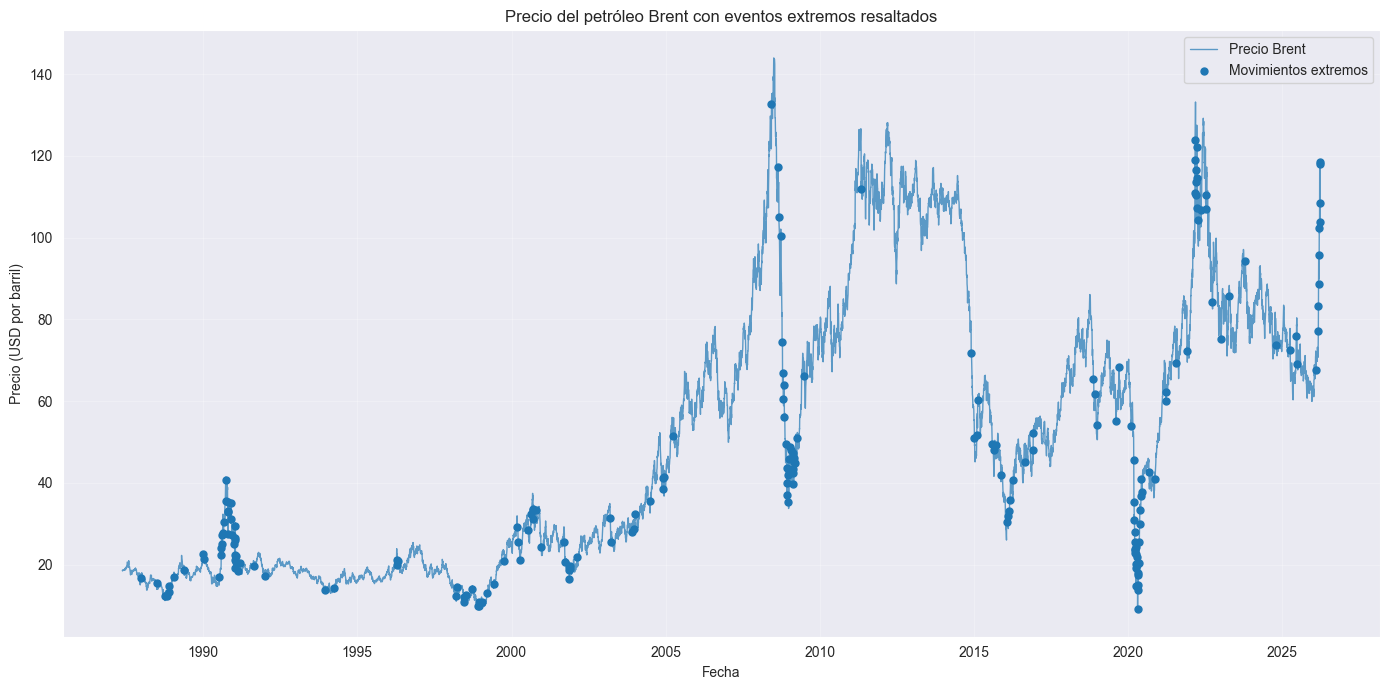

In [ ]:
data_ffill["price_diff"] = data_ffill["price"].diff() # Calcular la primera diferencia de la serie de precios del Brent. La función diff() de pandas calcula la diferencia entre cada valor y el valor anterior en la serie, lo que ayuda a eliminar tendencias y hacer que la serie sea estacionaria.
data_ffill["log_price"] = np.log(data_ffill["price"]) # Calcular el logaritmo de la serie de precios del Brent. La función np.log() de NumPy se aplica a cada valor de la columna "price" para obtener una nueva columna "log_price" que contiene los logaritmos de los precios. Esto puede ayudar a estabilizar la varianza y hacer que la serie sea más adecuada para ciertos análisis, como la detección de movimientos extremos.
data_ffill["log_diff"] = data_ffill["log_price"].diff() # Calcular la diferencia de los logaritmos de la serie de precios del Brent. La función diff() se aplica a la columna "log_price" para obtener una nueva columna "log_diff" que representa la diferencia entre cada valor de log_price y el valor anterior. Esto puede ayudar a identificar cambios porcentuales en los precios y detectar movimientos extremos en la serie.

lower_q = data_ffill["log_diff"].quantile(0.01)
upper_q = data_ffill["log_diff"].quantile(0.99)

extreme_moves = data_ffill[
    (data_ffill["log_diff"] < lower_q) | (data_ffill["log_diff"] > upper_q)   # Seleccionar las filas del DataFrame 'data_ffill' donde la diferencia de los logaritmos ('log_diff') es menor que el cuartil inferior (lower_q) o mayor que el cuartil superior (upper_q). Esto identifica los movimientos extremos en la serie de precios del Brent, ya que se consideran valores atípicos aquellos que se encuentran fuera del rango definido por los cuartiles.
].copy()

plt.figure(figsize=(14, 7))
plt.plot(data_ffill.index, data_ffill["price"], linewidth=1, alpha=0.7, label="Precio Brent")
plt.scatter(
    extreme_moves.index,
    extreme_moves["price"],
    s=25,
    label="Movimientos extremos"
)

plt.title("Precio del petróleo Brent con eventos extremos resaltados")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD por barril)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

- Esta gráfica calcula los movimientos extremos usando el 1% inferior y superior de la diferencia en logaritmos

- Para el caso del petróleo Brent, los eventos extremos están relacionados con fenomenos globales marcados por crisis, desaceleración e incertidumbre. Gracias a la visualización de los datos podemos marcar los siguientes eventos:
    - 2008: Crisis financiera global y colapso del precio del petróleo.
    - 2014 - 2016: Caida del precio del petróleo por exceso de oferta y desaceleración global.
    - 2020: Choque por la pandemia COVID-19.
    - Ultimos años: Incertidumbre geopolítica y tención internacional.


## 2.10. Resumen y recomendaciones

El análisis exploratorio de la serie del precio del petróleo Brent permitió identificar varios patrones relevantes para su posterior modelación. En primer lugar, la serie en niveles presenta una dinámica no estacionaria, evidenciada tanto por las pruebas formales de estacionariedad como por el comportamiento cambiante de la media y la varianza en distintas submuestras. En particular, los resultados de las pruebas ADF y KPSS indican de forma consistente que la serie original no es estacionaria. 

En segundo lugar, la serie exhibe una tendencia de largo plazo variable, caracterizada por periodos de crecimiento sostenido, caídas abruptas y fases de recuperación. El suavizamiento exponencial y la descomposición de la serie confirman que el comportamiento del precio del petróleo no sigue una trayectoria lineal simple, sino que responde a ciclos amplios y a cambios estructurales asociados al contexto internacional.

En tercer lugar, no se encontró evidencia sólida de una estacionalidad fuerte y regular. Tanto los diagramas de caja por mes y por día de la semana, como las funciones de autocorrelación y autocorrelación parcial, sugieren que la serie no está dominada por patrones estacionales recurrentes.

A partir de los hallazgos anteriores, el siguiente paso natural consiste en preparar la serie para su modelación econométrica y de pronóstico. Dado que la serie en niveles no es estacionaria, se recomienda trabajar con la primera diferencia o, preferiblemente, con la log-diferencia, ya que esta última permite una interpretación más cercana a cambios porcentuales y suele ser más apropiada en contextos financieros y de commodities.

En términos de modelización, una primera estrategia adecuada sería estimar un modelo ARIMA sobre la serie transformada, utilizando la evidencia de las gráficas ACF y PACF para orientar la selección preliminar de los parámetros para posteriormente dar uso a las herramientas de *Deep Learning* para la predicción de series temporales.